# 🧠 HYPERAKTIV: Integrated ADHD Multimodal Research Pipeline
## Final Unified Notebook — Phases 0–7

**Combines:**
- Binary + 3-way multiclass classification (ADHD vs ADD vs Non-ADHD)
- CPT-II profile clustering with multi-scope analysis
- Per-modality clustering with self-assessment, HRV, actigraphy
- Ground-truth separation line: ADHD + ADD vs Non-ADHD
- Statistical validation, effect sizes, permutation tests

**Design principles documented throughout each phase.**


---
## Phase 0 — Install Dependencies & Global Setup

**Design choice:** All random seeds are fixed globally for full reproducibility.
We install only what is needed: `kagglehub` for data, `kneed` for automatic elbow detection,
`shap` for interpretability, `tsfresh` for actigraphy features.


In [1]:
!pip install -q kagglehub kneed shap tsfresh xgboost lightgbm

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, random, re, warnings
from pathlib import Path

SEED = 42
random.seed(SEED); np.random.seed(SEED); os.environ['PYTHONHASHSEED'] = str(SEED)

PALETTE = {
    'ADHD':    '#D85A30',
    'ADD':     '#1D9E75',
    'Control': '#534AB7',
    'C0':      '#534AB7',
    'C1':      '#D85A30',
    'C2':      '#1D9E75',
    'C3':      '#E8A219',
}
def palette_k(frac): return plt.cm.tab10(frac)
import math
import itertools
import shap
import matplotlib.patches as mpatches
import statsmodels.stats.multitest as smm
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import (mannwhitneyu, kruskal, spearmanr,
                         chi2_contingency, fisher_exact, norm, skew, kurtosis)
from scipy.signal import welch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (LeaveOneOut, StratifiedKFold,
    cross_val_predict, cross_val_score, permutation_test_score)
from sklearn.metrics import (roc_auc_score, balanced_accuracy_score,
    confusion_matrix, classification_report, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, silhouette_score, davies_bouldin_score,
    adjusted_rand_score, normalized_mutual_info_score)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.base import clone
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from kneed import KneeLocator
from IPython.display import HTML, display


---
## Phase 1 — Data Ingestion & Preprocessing

**Design choices:**
- **CPT-II raw scores** (not T-scores) for binary classification: T-scores are already normalised
  toward the ADHD group, which artificially inflates diagnostic separation. Raw scores preserve
  the true signal distribution.
- **CPT-II T-scores** for clustering: T-scores put all five CPT-II dimensions on a common scale
  (mean=50, SD=10), which is necessary for K-Means (Euclidean) to treat dimensions equally.
- **HRV**: runs of ≥3 consecutive identical IBI values are device fill-in artifacts — removed.
  Only physiologically plausible IBI (300–2000 ms) retained.
- **Actigraphy**: Welch PSD + circadian features extracted; tsfresh features loaded when available.


In [3]:
import kagglehub
DATA_PATH = kagglehub.dataset_download('arashnic/adhd-diagnosis-data')
print('Dataset path:', DATA_PATH)

100%|██████████| 106M/106M [00:02<00:00, 38.1MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/arashnic/adhd-diagnosis-data/versions/2


In [4]:
# ── Patient info ──────────────────────────────────────────────────────────────
df_pat = pd.read_csv(Path(DATA_PATH, 'patient_info.csv'), sep=None, engine='python', encoding='utf-8-sig')

COL_MAP = {
    'ID', 'SEX', 'AGE', 'ADHD', 'ADD',
    'WURS', 'ASRS', 'MADRS', 'HADS_A', 'HADS_D', 'MED',
    'ANXIETY', 'BIPOLAR', 'UNIPOLAR', 'SUBSTANCE', 'OTHER',
}
SELF_COLS = ['ASRS','WURS','MADRS','HADS_A','HADS_D']
df_pat = df_pat.set_index('ID')
df_self = df_pat[SELF_COLS].copy()

COMORBID_COLS = ['ANXIETY','BIPOLAR','UNIPOLAR','SUBSTANCE','OTHER']
# Recode MINI Plus 9 (unknown) → NaN
for col in COMORBID_COLS: df_pat[col] = df_pat[col].replace(9, np.nan)

# ── 3-class diagnostic label ─────────────────────────────────────────────────
def primary_dx(row):
    if row.get('ADD', 0) == 1: return 'ADD'
    if row.get('ADHD', 0) == 1: return 'ADHD'
    return 'Non-ADHD'

df_pat['primary_dx'] = df_pat.apply(primary_dx, axis=1)
df_pat['n_comorbid'] = df_pat[COMORBID_COLS].sum(axis=1) if COMORBID_COLS else 0

print(f'N={len(df_pat)} | ADHD={df_pat.ADHD.sum()} | Control={(df_pat.ADHD==0).sum()}')
print(f'3-class distribution:\n{df_pat.primary_dx.value_counts().to_string()}')

N=103 | ADHD=51 | Control=52
3-class distribution:
primary_dx
Non-ADHD    52
ADHD        28
ADD         23


#### Comorbidity

- Explains HRV and actigraphy fail as classifiers: anxiety and bipolar disorder also dysregulate HRV and motor patterns
- "clinical control" group has these same physiological signatures, creating overlap that makes ADHD vs Non-ADHD separation nearly impossible from physiological signals alone

In [5]:
# ── EDA: Comorbidity count distribution in Non-ADHD group ────────────────────
non_adhd = df_pat[df_pat['primary_dx'] == 'Non-ADHD']
comorb_dist = non_adhd['n_comorbid'].value_counts().sort_index()

print('Non-ADHD comorbidity count distribution:')
for k, v in comorb_dist.items():
    print(f'  {int(k)} comorbidities: {v} people')

# IDs of Non-ADHD with 0 comorbidities
ids_0_comorb = df_pat[
    (df_pat['primary_dx'] == 'Non-ADHD') & (df_pat['n_comorbid'] == 0)
].index
print(f'IDs (Non-ADHD, 0 comorbidities): {ids_0_comorb.tolist()}')

Non-ADHD comorbidity count distribution:
  0 comorbidities: 2 people
  1 comorbidities: 16 people
  2 comorbidities: 17 people
  3 comorbidities: 15 people
  4 comorbidities: 2 people
IDs (Non-ADHD, 0 comorbidities): [61, 69]


### CPT-II
- Why raw scores for classification: T-scores are pre-normalised toward ADHD → inflated AUC
- Why General T-scores for clustering: standardized to population needed for Euclidean K-Means; comparable across features; no label leakage

In [6]:
cpt_raw = pd.read_csv(Path(DATA_PATH, 'CPT_II_ConnersContinuousPerformanceTest.csv'), sep=None, engine='python', encoding='utf-8-sig')
cpt_raw = cpt_raw.set_index('ID')

# Raw score columns
CPT_COLS = ['Raw Score Omissions','Raw Score Commissions',
            'Raw Score HitRT','Raw Score HitSE','Raw Score VarSE','Raw Score DPrime',
            'Raw Score Beta','Raw Score Perseverations','Raw Score HitRTBlock',
            'Raw Score HitSEBlock','Raw Score HitRTIsi','Raw Score HitSEIsi']

# T-score columns for clustering
CPT_CLUSTER_TARGETS = ['Adhd Confidence Index','General TScore Omissions',
                     'General TScore Commissions','General TScore HitRT',
                     'General TScore HitSE','General TScore VarSE',
                     'General TScore DPrime','General TScore Beta',
                     'General TScore Perseverations','General TScore HitRTBlock',
                     'General TScore HitSEBlock', 'General TScore HitRTIsi',
                     'General TScore HitSEIsi']

df_cpt = cpt_raw[CPT_COLS + CPT_CLUSTER_TARGETS].copy()
zero_mask = (df_cpt[['Raw Score VarSE','Raw Score HitRT', 'Raw Score HitSE']].fillna(0)==0).all(axis=1)
df_cpt = df_cpt[~zero_mask]
print(f'original: {cpt_raw.shape} after cleaning CPT-II: {df_cpt.shape}') # should remove 2 instances

original: (99, 785) after cleaning CPT-II: (97, 25)


#### EDA: Analyze Blue (Control) v.s. Orange (ADHD):

1. Omissions: ADHD much higher → strong inattention signal (p ≪ 0.001)
2. Commissions: ADHD higher → clear impulsivity marker (p ≪ 0.001)
3. VarSE (RT variability): ADHD much more spread → inconsistent attention (p ≪ 0.001)
4. Perseverations: ADHD elevated → response instability / impulsive responding (p ≪ 0.001)


---


Raw CPT-II metrics successfully replicates classic ADHD CPT profile, despite Distributions still overlap substantially:
- ↑ omissions → inattention
- ↑ commissions → impulsivity
- ↑ variability → instability
- ↓ d′ → poorer signal detection

In [7]:
def clean_id_index(df):
    idx = df.index.astype(str).str.strip()
    idx = idx.str.lstrip('0')  # optional
    return df.set_index(idx)

df_cpt = clean_id_index(df_cpt)
df_pat = clean_id_index(df_pat)

Final joined shape: (97, 28)
EDA sample size = 97
ADHD n = 50 | Control n = 47


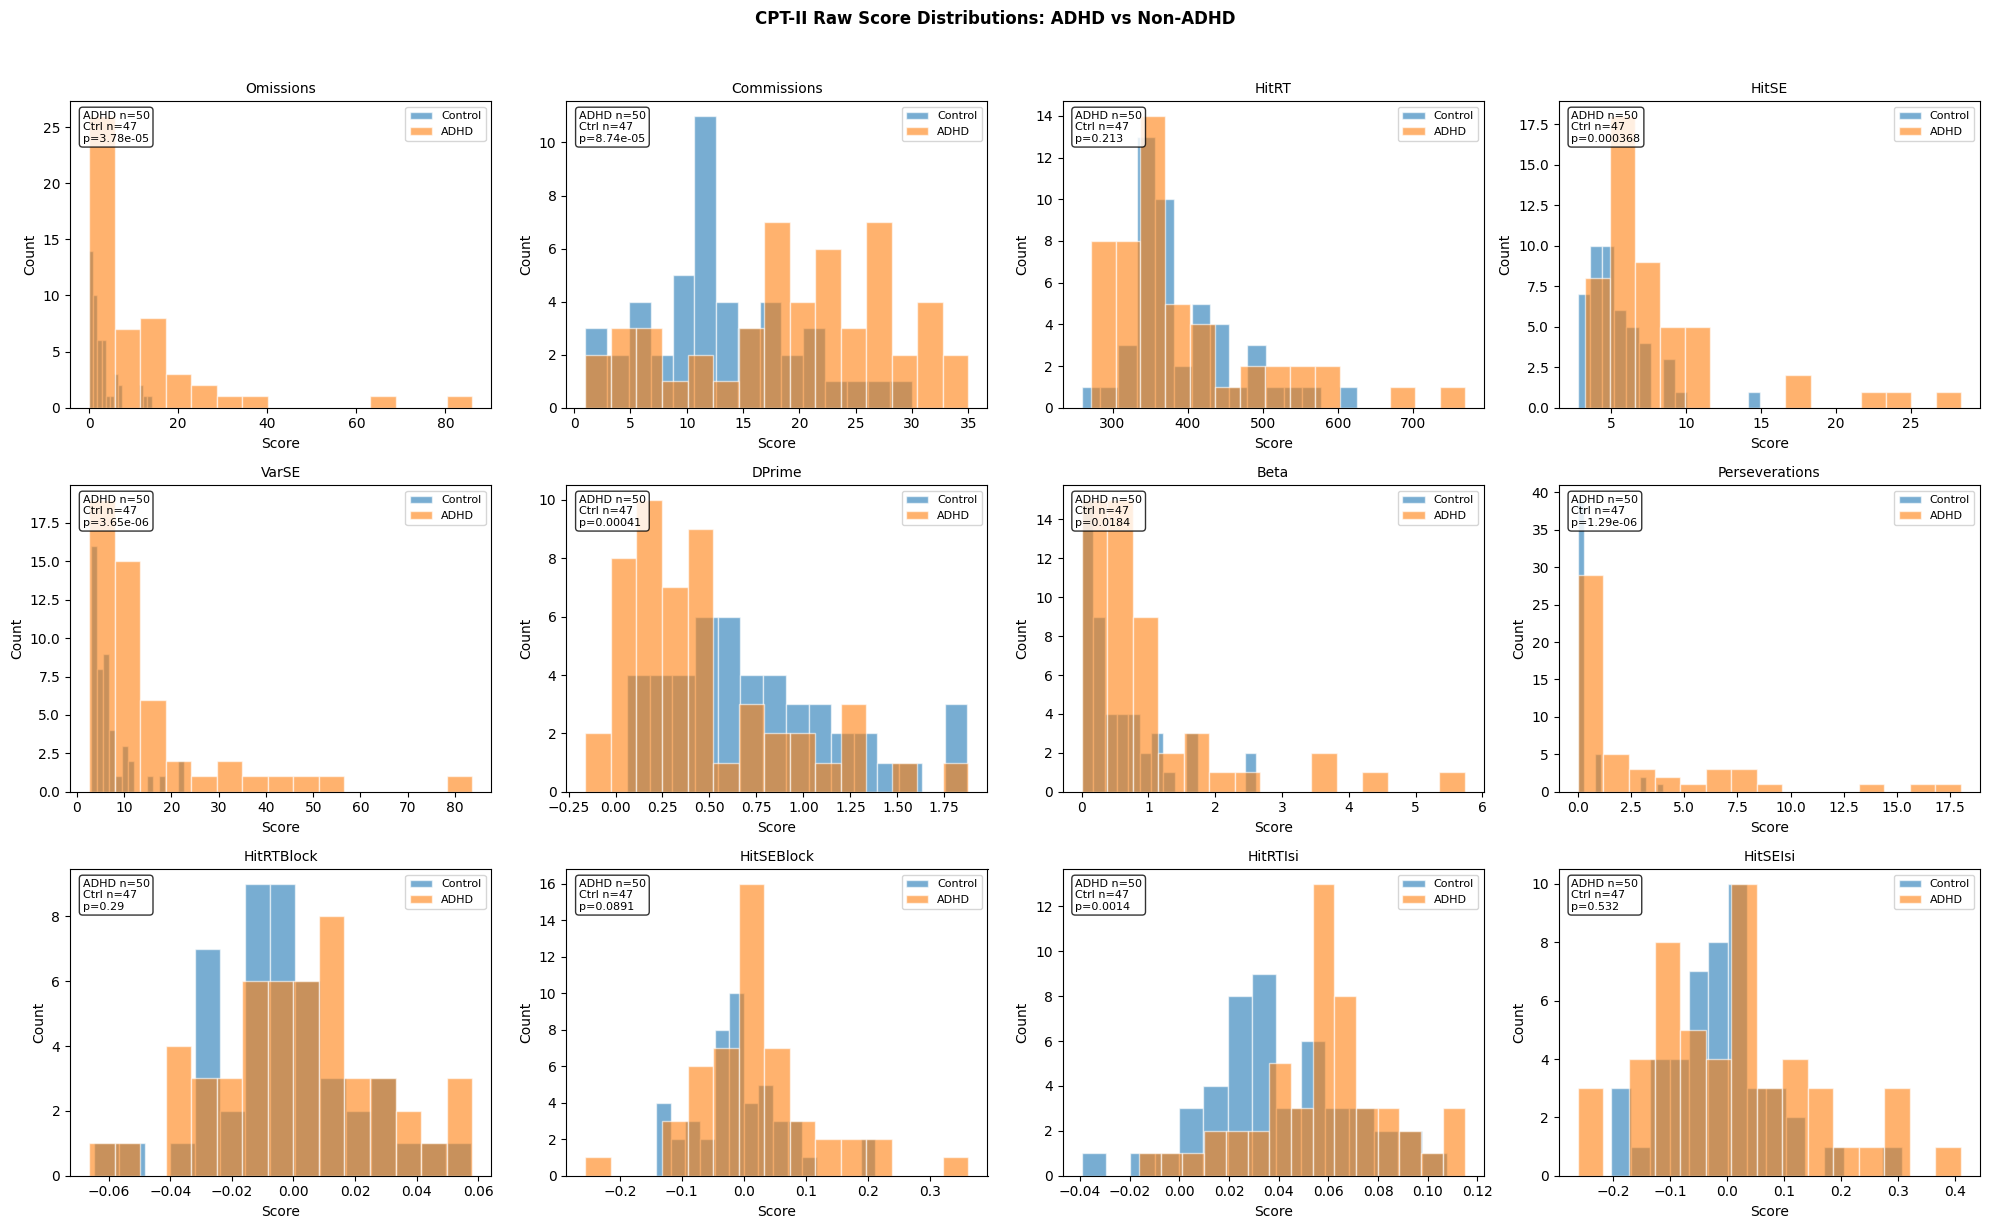

In [8]:
# ── EDA 1: CPT-II raw score distributions by ADHD group ──────────────────────
df_eda = df_cpt.join(df_pat[['ADHD', 'ADD', 'primary_dx']], how='inner')

print("Final joined shape:", df_eda.shape)
print(f'EDA sample size = {len(df_eda)}')
print(f'ADHD n = {(df_eda["ADHD"] == 1).sum()} | Control n = {(df_eda["ADHD"] == 0).sum()}')

# Layout
n_feats = len(CPT_COLS)
ncols = 4
nrows = math.ceil(n_feats / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, feat in enumerate(CPT_COLS):
    ax = axes[i]

    adhd_vals = df_eda.loc[df_eda['ADHD'] == 1, feat].dropna()
    ctrl_vals = df_eda.loc[df_eda['ADHD'] == 0, feat].dropna()

    ax.hist(ctrl_vals, bins=15, alpha=0.6, label='Control', edgecolor='white')
    ax.hist(adhd_vals, bins=15, alpha=0.6, label='ADHD', edgecolor='white')

    # Mann–Whitney U test
    if len(adhd_vals) >= 2 and len(ctrl_vals) >= 2:
        _, p = mannwhitneyu(adhd_vals, ctrl_vals, alternative='two-sided')
        ax.text(
            0.03, 0.97,
            f'ADHD n={len(adhd_vals)}\nCtrl n={len(ctrl_vals)}\np={p:.3g}',
            transform=ax.transAxes,
            va='top',
            ha='left',
            fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )

    ax.set_title(feat.replace('Raw Score ', ''), fontsize=10)
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

for j in range(n_feats, len(axes)): fig.delaxes(axes[j])

plt.suptitle('CPT-II Raw Score Distributions: ADHD vs Non-ADHD', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_01_cptii_raw_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

### Acitivity Data -- sampling: 1 sample/min; avg. duration: 6–7 days (~8k–10k points)

goal: ADHD → fragmentation, instability, hyperactivity

#### Welch Power Spectral Density (PSD)

**Interpretation:**  
Welch’s method estimates the power spectral density by:
1. Splitting the signal into overlapping segments  
2. Applying a window to each segment  
3. Computing the Fourier transform  
4. Averaging the power across segments  

This reduces noise and gives a stable estimate of how signal power is distributed across frequencies.

#### Intra-daily Variability (IV)

$$
IV = \frac{n \cdot \sum_{t=1}^{n-1} (x_{t+1} - x_t)^2}
{(n-1) \cdot \sum_{t=1}^{n} (x_t - \bar{x})^2}
$$

- $x_t$: activity at time $t$
- $\bar{x}$: mean activity
- $n$: number of time points

**Interpretation:** Measures how frequently activity switches between states (fragmentation).

#### Inter-daily Stability (IS)

$$
IS = \frac{n \cdot \sum_{h=1}^{24} (\bar{x}_h - \bar{x})^2}
{24 \cdot \sum_{t=1}^{n} (x_t - \bar{x})^2}
$$

- $\bar{x}_h$: mean activity at hour $h$ across days  
- $\bar{x}$: overall mean activity  
- $n$: total number of time points  

**Interpretation:** Measures how consistent the daily activity pattern is across days.

In [9]:
# ── Actigraphy ────────────────────────────────────────────────────────────────
def extract_actigraphy(fpath):
    d = pd.read_csv(fpath, sep=None, engine='python', encoding='utf-8-sig')
    x = d['ACTIVITY'].dropna().values.astype(float)

    row = {}
    # Statistical for intensity + variability
    row['act_mean']     = np.mean(x) # overall activity level, hyperactivity or not
    row['act_std']      = np.std(x) # ADHD often more variable behaviors
    row['act_cv']       = np.std(x) / (np.mean(x) + 1e-9)
    row['act_skew']     = skew(x) # shape of distribution, burst of activity or steady trend
    row['act_kurt']     = kurtosis(x) # 峰度
    row['act_iqr']      = np.percentile(x, 75) - np.percentile(x, 25) # spread/outliers = extremes
    row['act_p90']      = np.percentile(x, 90)
    row['act_inactive'] = (x < np.percentile(x, 10)).mean() # inactivity / rest periods
    row['act_peaks']    = int((np.diff(np.sign(np.diff(x))) < 0).sum()) # number of local spikes, impulsivity
    # temporal stability via autocorrelation
    row['act_ac1h']      = float(pd.Series(x).autocorr(60)) # Predictability over short-term --> low = erratic, ADHD
    row['act_ac24h'] = float(pd.Series(x).autocorr(1440)) if len(x) > 1500 else np.nan # daily pattern, low = disruptive

    # 1. Spectral band power (Welch) --> power density for each frequency bins
    # default fs = 1.0 for 1 sample per minute
    # nperseg = 1440 minutes = 1 day for each chunk long, stable PSD (Fast Fourier-Transfer power spectral density)
    freqs, psd = welch(x, fs=1.0, nperseg=min(1440, len(x)))

    # 2. integrate area under the psd density curve = total power in range
    def band(lo, hi): # Find total power inside that frequency band
        m = (freqs >= lo) & (freqs < hi)
        return np.trapezoid(psd[m], freqs[m]) if m.any() else 0.0

    valid = (freqs >= 1/(6*60)) & (freqs < 1/5) # 5 min to 6 h
    total = np.trapezoid(psd[valid], freqs[valid]) + 1e-10

    psd_sub_hourly = band(1/60, 1/5)            # 5–60 min < 1h
    psd_intra_daily = band(1/(2*60), 1/60)       # 1-2h
    psd_ultradian = band(1/(6*60), 1/(2*60))   # 2–6 h, 1.5h to 20h
    psd_slow = band(1/(12*60), 1/(6*60))  # 6–12 h
    psd_circadian = band(1/(36*60), 1/(12*60)) # 12–36 h]

    row['psd_ultradian_norm']   = psd_ultradian / total
    row['psd_intra_daily_norm'] = psd_intra_daily / total
    row['psd_sub_hourly_norm']  = psd_sub_hourly / total
    row['psd_circadian_norm']   = psd_circadian / total
    row['psd_slow_norm']        = psd_slow / total

    # Circadian features
    if len(x) > 24 * 60:
        hourly = np.array([x[i*60:(i+1)*60].mean() for i in range(len(x)//60)])
        if len(hourly) > 24:
            n_h = len(hourly)
            m10 = np.array([hourly[i:i+10].mean() for i in range(n_h - 9)])
            l5  = np.array([hourly[i:i+5].mean()  for i in range(n_h - 4)])
            row['M10_onset'] = float(np.argmax(m10) % 24) # person's most active 10h
            row['L5_onset']  = float(np.argmin(l5)  % 24) # person's least active 5h -> rest/sleep
            # relative amplitude, low = flattened day v.s. night contrast, ADHD
            row['RA']        = float((m10.max() - l5.min()) / (m10.max() + l5.min() + 1e-10))
            h_mu = hourly.mean()
            # intra-daily variability, higher = more switching, ADHD = how jumpy / total variance
            row['IV'] = float((n_h * np.sum(np.diff(hourly)**2)) / ((n_h-1) * np.sum((hourly - h_mu)**2) + 1e-10))
            # inter-daily stability, low IS = irregular schedule, ADHD = mean activity variance at each hour of day / average across all days
            row['IS'] = float((n_h * np.sum((hourly - h_mu)**2)) / (24 * np.sum((x - x.mean())**2) + 1e-10))
    return row

act_rows = []
for fpath in sorted((Path(DATA_PATH)/'activity_data').glob('*.csv')):
    feats = extract_actigraphy(fpath)
    if feats:
        feats['ID'] = int(fpath.stem.split('_')[-1])
        act_rows.append(feats)
df_act = pd.DataFrame(act_rows).set_index('ID')
ACT_COLS = [c for c in df_act.columns if c not in ('ID',)]
print(f'Actigraphy: {df_act.shape}')

Actigraphy: (85, 21)


HRV
1. Quality control:

Runs of ≥ 3 consecutive IDENTICAL IBI values are device fill-in artifacts --> These are replaced with NaN and excluded from feature computation.

2. EXTRASYSTOLE RULE (clinical standard):

Any IBI that deviates > 20% from a rolling median (window=11 beats) is flagged as a potential ectopic beat.  The flag window is ±1 beat around the outlier (the premature beat + its compensatory long beat).

In [10]:
# ── HRV / IBI ─────────────────────────────────────────────────────────────────
def clean_ibi(df_hrv):
    df_hrv = df_hrv[(df_hrv.iloc[:,-1] > 300) & (df_hrv.iloc[:,-1] < 2000)].copy()
    vals = df_hrv.iloc[:,-1].values
    # Remove device-fill runs (≥3 consecutive identical)
    mask = np.ones(len(vals), dtype=bool)
    for i in range(1, len(vals)-1):
        if vals[i] == vals[i-1] == vals[i+1]:
            mask[i] = False
    return df_hrv[mask]

def hrv_features(ibi_vals):
    if len(ibi_vals) < 30: return {}
    diffs = np.diff(ibi_vals)
    return {
        'mean_nni': np.mean(ibi_vals),
        'sdnn': np.std(ibi_vals),
        'rmssd': np.sqrt(np.mean(diffs**2)),
        'pnn50': np.mean(np.abs(diffs) > 50),
        'hrv_skew': skew(ibi_vals),
    }

hrv_rows = []
for fpath in sorted((Path(DATA_PATH)/'hrv_data').glob('*.csv')):
    df_hrv = pd.read_csv(fpath, sep=None, engine='python', encoding='utf-8-sig')
    df_hrv['hrv'] = pd.to_numeric(df_hrv['HRV'])
    df_hrv = clean_ibi(df_hrv)
    f = hrv_features(df_hrv['hrv'])

    f['ID'] = int(fpath.stem.split('_')[-1])
    hrv_rows.append(f)

df_hrv = pd.DataFrame(hrv_rows).set_index('ID')
HRV_COLS = list(df_hrv.columns)
print(f'HRV: {df_hrv.shape}, columns: {HRV_COLS}')

HRV: (80, 5), columns: ['mean_nni', 'sdnn', 'rmssd', 'pnn50', 'hrv_skew']


### All modalities

In [11]:
# ── Merge all modalities — Per-modality participant sets + all-overlap df ────
df_cpt  = clean_id_index(df_cpt)
df_act  = clean_id_index(df_act)
df_hrv  = clean_id_index(df_hrv)
df_self = clean_id_index(df_self)
df_pat  = clean_id_index(df_pat)

ids_cpt  = set(df_cpt.index)
ids_act  = set(df_act.index)
ids_hrv  = set(df_hrv.index)
ids_self = set(df_self.index)
ids_pat  = set(df_pat.index)

# Pairwise overlaps — used for individual modality joins
ids_cpt_pat   = ids_cpt  & ids_pat
ids_act_pat   = ids_act  & ids_pat
ids_hrv_pat   = ids_hrv  & ids_pat
ids_self_pat  = ids_self & ids_pat
ids_all       = ids_cpt  & ids_act & ids_hrv & ids_self & ids_pat

# Feature column lists
cpt_avail  = [c for c in CPT_COLS            if c in df_cpt.columns]
act_avail  = [c for c in ACT_COLS            if c in df_act.columns]
hrv_avail  = [c for c in HRV_COLS            if c in df_hrv.columns]
self_avail = [c for c in SELF_COLS           if c in df_self.columns]
ALL_FEATS  = cpt_avail + act_avail + hrv_avail + self_avail

def build_modality_df(feat_cols, source_df, id_set):
    pids = sorted(id_set & ids_pat)
    avail_cols = [c for c in feat_cols if c in source_df.columns]
    base = df_pat.loc[pids, ['ADHD', 'primary_dx']].copy()
    if avail_cols:
        base = base.join(source_df[avail_cols], how='left')
    return base

df_cpt_only  = build_modality_df(cpt_avail,  df_cpt,  ids_cpt_pat)
df_act_only  = build_modality_df(act_avail,  df_act,  ids_act_pat)
df_hrv_only  = build_modality_df(hrv_avail,  df_hrv,  ids_hrv_pat)
df_self_only = build_modality_df(self_avail, df_self, ids_self_pat)

print(f'\nPer-modality df shapes:')
print(f'  CPT only:         {df_cpt_only.shape}')
print(f'  Actigraphy only:  {df_act_only.shape}')
print(f'  HRV only:         {df_hrv_only.shape}')
print(f'  Self-report only: {df_self_only.shape}')

# ── All-overlap df (n=64) — kept for clustering phases ────────────────────────
pids_all = sorted(ids_all)
df = (df_pat.loc[pids_all, ['ADHD', 'primary_dx']]
      .join(df_cpt[cpt_avail + CPT_CLUSTER_TARGETS], how='left')
      .join(df_act[act_avail], how='left')
      .join(df_hrv[hrv_avail], how='left')
      .join(df_self[self_avail], how='left'))
print(f'\nAll-modality merged df shape (n=64): {df.shape}')

# ── MODALITY_ID_SETS — maps block name → participant id set ──────────────────
MODALITY_ID_SETS = {
    'CPT only':          ids_cpt_pat,
    'Activity only':     ids_act_pat,
    'HRV only':          ids_hrv_pat,
    'Self-report only':  ids_self_pat,
    'CPT + Activity':    ids_cpt_pat  & ids_act_pat,
    'CPT + HRV':         ids_cpt_pat  & ids_hrv_pat,
    'CPT + Self-report': ids_cpt_pat  & ids_self_pat,
    'CPT + Act + HRV':   ids_cpt_pat  & ids_act_pat  & ids_hrv_pat,
    'All modalities':    ids_all,
}

def build_block_df(feat_list, id_set):
    pids = sorted(id_set & ids_pat)
    base = df_pat.loc[pids, ['ADHD', 'primary_dx']].copy()
    for df_mod, cols in [(df_cpt,  CPT_COLS + CPT_CLUSTER_TARGETS),
                          (df_act,  ACT_COLS),
                          (df_hrv,  HRV_COLS),
                          (df_self, SELF_COLS)]:
        avail_cols = [c for c in cols if c in df_mod.columns and c in feat_list]
        if avail_cols:
            base = base.join(df_mod[avail_cols], how='left')
    return base


Per-modality df shapes:
  CPT only:         (97, 14)
  Actigraphy only:  (85, 23)
  HRV only:         (80, 7)
  Self-report only: (103, 7)

All-modality merged df shape (n=64): (64, 58)


In [12]:
# ── Simple Spearman correlation across all features ───────────────────────────
from scipy.stats import spearmanr
feat_cols = [c for c in ALL_FEATS if c in df.columns]
df_corr = df[feat_cols].apply(pd.to_numeric, errors='coerce').copy()
feat_cols = df_corr.columns.tolist()

print(f'Correlation input shape: {df_corr.shape}')
print(f'Number of features: {len(feat_cols)}')

# initialize result matrices
rho_mat = pd.DataFrame(np.nan, index=feat_cols, columns=feat_cols)
p_mat   = pd.DataFrame(np.nan, index=feat_cols, columns=feat_cols)

for i, ci in enumerate(feat_cols):
    rho_mat.loc[ci, ci] = 1.0
    p_mat.loc[ci, ci] = 0.0

    for j in range(i + 1, len(feat_cols)):   # start at i+1, not i
        cj = feat_cols[j]

        pair = df_corr[[ci, cj]].dropna()
        if len(pair) < 3: continue
        if pair[ci].nunique() < 2 or pair[cj].nunique() < 2: continue

        r, p = spearmanr(pair[ci], pair[cj])
        rho_mat.loc[ci, cj] = r
        rho_mat.loc[cj, ci] = r
        p_mat.loc[ci, cj]   = p
        p_mat.loc[cj, ci]   = p

print('\nSpearman rho matrix:')
display(rho_mat.round(3))
# print('\nSpearman p-value matrix:')
# display(p_mat.round(4))

Correlation input shape: (64, 43)
Number of features: 43

Spearman rho matrix:


,Raw Score Omissions,Raw Score Commissions,Raw Score HitRT,Raw Score HitSE,Raw Score VarSE,Raw Score DPrime,Raw Score Beta,Raw Score Perseverations,Raw Score HitRTBlock,Raw Score HitSEBlock,...,mean_nni,sdnn,rmssd,pnn50,hrv_skew,ASRS,WURS,MADRS,HADS_A,HADS_D
Raw Score Omissions,1.000,0.415,0.123,0.732,0.727,-0.355,0.332,0.422,0.110,0.302,...,0.012,0.166,0.158,0.123,0.326,0.403,0.482,0.385,0.403,0.209
Raw Score Commissions,0.415,1.000,-0.470,0.282,0.442,-0.867,-0.039,0.583,0.167,0.322,...,-0.099,0.064,0.083,0.061,0.219,0.571,0.505,0.251,0.222,0.187
Raw Score HitRT,0.123,-0.470,1.000,0.325,0.083,0.313,0.349,-0.243,-0.074,-0.307,...,0.143,-0.007,-0.007,-0.070,0.041,-0.260,-0.186,0.036,-0.006,-0.001
Raw Score HitSE,0.732,0.282,0.325,1.000,0.858,-0.251,0.442,0.462,0.224,0.219,...,-0.041,0.080,0.177,0.056,0.334,0.353,0.373,0.241,0.176,0.124
Raw Score VarSE,0.727,0.442,0.083,0.858,1.000,-0.335,0.218,0.476,0.273,0.289,...,-0.150,0.010,0.121,-0.020,0.327,0.374,0.454,0.287,0.235,0.216
Raw Score DPrime,-0.355,-0.867,0.313,-0.251,-0.335,1.000,-0.078,-0.413,-0.069,-0.243,...,0.022,-0.133,-0.073,-0.092,-0.133,-0.471,-0.449,-0.151,-0.138,-0.094
Raw Score Beta,0.332,-0.039,0.349,0.442,0.218,-0.078,1.000,0.190,-0.083,0.063,...,-0.129,0.069,0.098,0.085,0.244,0.064,0.130,0.050,-0.037,-0.167
Raw Score Perseverations,0.422,0.583,-0.243,0.462,0.476,-0.413,0.190,1.000,0.110,0.203,...,-0.064,0.134,0.160,0.188,0.217,0.418,0.514,0.161,0.074,0.013
Raw Score HitRTBlock,0.110,0.167,-0.074,0.224,0.273,-0.069,-0.083,0.110,1.000,0.364,...,0.156,-0.085,0.003,0.006,-0.056,0.219,0.101,0.123,-0.045,0.173
Raw Score HitSEBlock,0.302,0.322,-0.307,0.219,0.289,-0.243,0.063,0.203,0.364,1.000,...,0.032,-0.058,-0.003,0.074,0.065,0.355,0.197,0.159,0.110,0.056


- VarSE ↔ Omissions = 0.727 [Expected]: A strong positive Spearman r. Patients who miss more targets (high omissions) also show more variable reaction time standard error — both are inattention signatures

- DPrime ↔ Commissions = −0.867 [Expected]: The strongest negative correlation. Patients who respond to non-targets (commission errors / impulsivity) have systematically lower d′ — they cannot distinguish signal from noise

- Near-zero Spearman between Actigraphy & CPT-II: Motor activity during daily life has almost no monotonic relationship with cognitive test performance in a clinical lab setting.

---
## Phase 2 — Binary Classification: ADHD vs Non-ADHD (CPT-II Baseline)

**Design choices:**

### Why Logistic Regression (not Random Forest)?
- **Small sample** (n≈100): Random Forest overfits on small datasets. Logistic Regression
  with L2 regularisation (C=0.1) provides a regularised, interpretable baseline.
- **Sparse features**: CPT-II has only 5 dimensions — LR is adequate and more stable.

### Why Stratified 10-fold CV (not LOO)?
- 10-fold CV is preferred over LOO because LOO produces high-variance AUC estimates on
  small datasets. Stratified folds guarantee class balance in each fold.

### Why these metrics?
| Metric | Why |
|--------|-----|
| **ROC-AUC** | Threshold-free ranking — asks "Can the model rank ADHD > Control?" |
| **PR-AUC** | Focuses on the positive class; appropriate when ADHD diagnosis has higher clinical cost |
| **MCC** | Best single metric for imbalanced binary classification — accounts for all four confusion matrix cells |
| **Balanced Accuracy** | Arithmetic mean of sensitivity + specificity; interpretable with class imbalance |
| **Permutation p** | Tests whether AUC exceeds chance; guards against spurious results on small n |


In [13]:
# ── Shared CV pipeline ────────────────────────────────────────────────────────
def cv_metrics_10fold(X, y):
    """Stratified 10-fold CV: AUC, PR-AUC, MCC, BalAcc, permutation p."""
    if len(np.unique(y)) < 2 or len(X) < 8: return {}
    clf = make_pipe(LogisticRegression(C=0.1, max_iter=1000, random_state=SEED, class_weight='balanced'))
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
    proba = cross_val_predict(clf, X, y, cv=cv, method='predict_proba')[:, 1]
    pred  = cross_val_predict(clf, X, y, cv=cv, method='predict')
    _, _, perm_p = permutation_test_score(clf, X, y, cv=cv, scoring='roc_auc',
                                          n_permutations=500, random_state=SEED)
    return {
        'auc':      roc_auc_score(y, proba), # 0.5 = chance, 1.0 = perfect ranking ability (Can model rank ADHD > control correctly?)
        'auprc':    average_precision_score(y, proba), # PR-AUC --> area under precision-recall curve, Focuses on positive class (e.g., ADHD)
        'accuracy': accuracy_score(y, pred),
        'precision':precision_score(y, pred, zero_division=0),
        'recall':   recall_score(y, pred, zero_division=0),
        'f1':       f1_score(y, pred, zero_division=0),
        'mcc':      matthews_corrcoef(y, pred), # biomedical binary classification, +1 = perfect, 0 = random, -1 = disagreement
        'bacc':     balanced_accuracy_score(y, pred), # balanced accuracy for imbalanced classes --> (sensitivity [recall for class 1]+ specificity [recall for class 2]) / 2
        'perm_p':   perm_p,
        'proba':    proba,
        'pred':     pred,
    }

def loo_auc(X, y):
    """LOO-CV for small subgroups (< 30 samples)."""
    if len(np.unique(y)) < 2 or len(X) < 8: return {}
    clf = make_pipe(LogisticRegression(C=0.1, max_iter=2000, random_state=SEED, class_weight='balanced'))
    loo   = LeaveOneOut()
    proba = cross_val_predict(clf, X, y, cv=loo, method='predict_proba')[:, 1]
    pred  = cross_val_predict(clf, X, y, cv=loo, method='predict')
    _, counts = np.unique(y, return_counts=True)
    n_splits = min(5, counts.min())
    perm_p = np.nan
    if n_splits >= 2:
        cv_p = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
        _, _, perm_p = permutation_test_score(clf, X, y, cv=cv_p, scoring='roc_auc',
                                              n_permutations=500, random_state=SEED)
    return {'auc': roc_auc_score(y, proba),
            'bacc': balanced_accuracy_score(y, pred),
            'perm_p': perm_p,
            'proba': proba,
            'pred': pred}

print('✅ CV pipeline defined.')

✅ CV pipeline defined.


### 2.1 CPT-II Baseline: How Much Can Cognitive Data (CPT-II) Contribute Alone?

1. Can the CPT-II features classify ADHD vs non-ADHD psychiatric controls?
2. ADHD vs major diagnostic subgroups,
3. predict continuous ADHD Confidence Index.

In [14]:
# ── Model Comparison: 10-Fold Cross-Validation ────────────────────────────────
def make_pipe(clf, scale=True):
    steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale: steps.append(('scaler', StandardScaler()))
    steps.append(('clf', clf))
    return Pipeline(steps)

def evaluate_models_10fold(X, y):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
    models = {
        # Baselines
        'RB': DummyClassifier(strategy='stratified', random_state=SEED),   # random baseline
        'MIN': DummyClassifier(strategy='constant', constant=1),           # always predict ADHD
        'MAJ': DummyClassifier(strategy='most_frequent'),                  # always predict majority class

        # Main models
        'LR': make_pipe(LogisticRegression(
            C=0.1, max_iter=1000, class_weight='balanced', random_state=SEED
        ), scale=True),

        'RF': make_pipe(RandomForestClassifier(
            n_estimators=200, max_depth=None, class_weight='balanced', random_state=SEED
        ), scale=False),

        'XGB': make_pipe(XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.9,
            colsample_bytree=0.9, eval_metric='logloss', random_state=SEED
        ), scale=False),
        'LGBM': make_pipe(LGBMClassifier(
            n_estimators=200, learning_rate=0.05, num_leaves=31, class_weight='balanced',
            random_state=SEED, verbose=-1
        ), scale=False)
    }

    rows = []
    cm_store = {}
    for name, model in models.items():
        fold_metrics = []
        fold_cms = []

        for train_idx, test_idx in cv.split(X, y):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            clf = clone(model)
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            y_proba = clf.predict_proba(X_test)[:, 1]

            fold_metrics.append({
                'AUC': roc_auc_score(y_test, y_proba),
                'Accuracy': accuracy_score(y_test, y_pred),
                'Precision': precision_score(y_test, y_pred, zero_division=0),
                'Recall': recall_score(y_test, y_pred, zero_division=0),
                'F1-Score': f1_score(y_test, y_pred, zero_division=0),
                'MCC': matthews_corrcoef(y_test, y_pred),
            })

            fold_cms.append(confusion_matrix(y_test, y_pred, labels=[0, 1]))
        cm_store[name] = fold_cms

        df_fold = pd.DataFrame(fold_metrics)
        row = {'Model': name}
        for col in ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'MCC']:
            row[col] = df_fold[col].mean()
        rows.append(row)

    results = pd.DataFrame(rows)
    order = ['RB', 'MIN', 'MAJ', 'LR', 'RF', 'XGB', 'LGBM']
    results['__order'] = results['Model'].map({m: i for i, m in enumerate(order)})
    results = results.sort_values('__order').drop(columns='__order').reset_index(drop=True)
    return results, cm_store

In [15]:
def format_results_table(results, best_metric='AUC'):
    results_fmt = results.copy()

    main_models = ~results_fmt['Model'].isin(['RB', 'MIN', 'MAJ'])
    metric_cols = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'MCC']

    # numeric rounding
    for c in metric_cols:
        results_fmt[c] = results_fmt[c].map(lambda x: f'{x:.2f}')

    # bold best among main models
    for c in metric_cols:
        best_idx = results.loc[main_models, c].idxmax()
        results_fmt.loc[best_idx, c] = f'**{results_fmt.loc[best_idx, c]}**'

    return results_fmt

def plot_avg_confusion_matrix(cm_list, title='Average confusion matrix'):
    cm_mean = np.mean(np.stack(cm_list, axis=0), axis=0)
    cm_norm = cm_mean / cm_mean.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    labels = ['Non-ADHD', 'ADHD']
    ax.set(
        xticks=[0, 1], yticks=[0, 1], xticklabels=labels, yticklabels=labels,
        xlabel='Predicted label', ylabel='True label', title=title
    )

    for i in range(2):
        for j in range(2):
            ax.text(
                j, i,
                f'{cm_norm[i, j]:.2f}\n(n={cm_mean[i, j]:.1f})',
                ha='center', va='center',
                color='white' if cm_norm[i, j] > 0.5 else 'black',
                fontsize=10
            )

    plt.tight_layout()
    plt.show()


CPT only [n = 97]
Model      AUC Accuracy Precision   Recall F1-Score      MCC
   RB     0.53     0.52      0.55     0.44     0.49     0.05
  MIN     0.50     0.52      0.52     1.00     0.68     0.00
  MAJ     0.50     0.52      0.52     1.00     0.68     0.00
   LR     0.82 **0.73**  **0.79**     0.68     0.71 **0.50**
   RF     0.81     0.69      0.73     0.70     0.67     0.41
  XGB **0.83**     0.73      0.76 **0.74** **0.73**     0.49
 LGBM     0.81     0.71      0.74     0.70     0.70     0.45


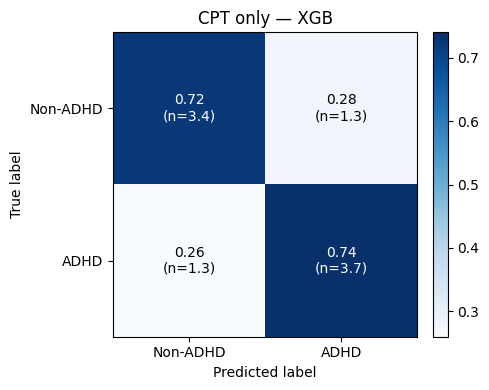


Activity only [n = 85]
Model      AUC Accuracy Precision   Recall F1-Score      MCC
   RB     0.52     0.52      0.55     0.49     0.52     0.04
  MIN     0.50     0.53      0.53     1.00     0.69     0.00
  MAJ     0.50     0.53      0.53     1.00     0.69     0.00
   LR **0.48** **0.54**  **0.59** **0.58** **0.57** **0.07**
   RF     0.37     0.42      0.48     0.53     0.47    -0.18
  XGB     0.42     0.40      0.44     0.47     0.44    -0.24
 LGBM     0.38     0.43      0.44     0.41     0.41    -0.17


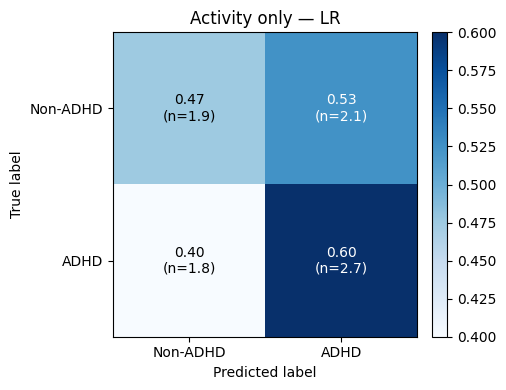


HRV only [n = 80]
Model      AUC Accuracy Precision   Recall F1-Score       MCC
   RB     0.50     0.50      0.47     0.49     0.48     -0.00
  MIN     0.50     0.47      0.47     1.00     0.64      0.00
  MAJ     0.50     0.53      0.00     0.00     0.00      0.00
   LR **0.43**     0.44      0.40     0.35     0.35     -0.13
   RF     0.41 **0.45**  **0.41** **0.41** **0.39** **-0.09**
  XGB     0.38     0.40      0.38     0.33     0.35     -0.20
 LGBM     0.39     0.36      0.32     0.31     0.30     -0.28


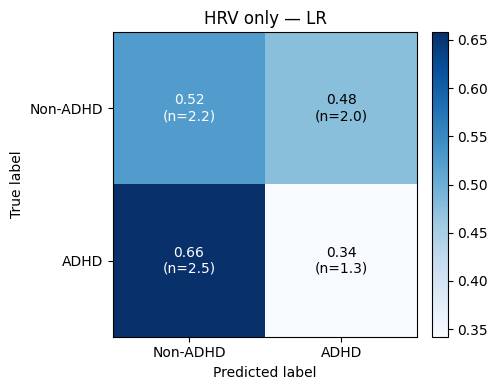


Self-report only [n = 103]
Model      AUC Accuracy Precision   Recall F1-Score      MCC
   RB     0.53     0.53      0.55     0.45     0.49     0.06
  MIN     0.50     0.51      0.51     1.00     0.68     0.00
  MAJ     0.50     0.51      0.51     1.00     0.68     0.00
   LR **0.84**     0.73  **0.77**     0.70     0.72     0.47
   RF     0.78     0.72      0.73     0.70     0.70     0.45
  XGB     0.81     0.71      0.73     0.68     0.68     0.43
 LGBM     0.81 **0.75**      0.77 **0.74** **0.74** **0.51**


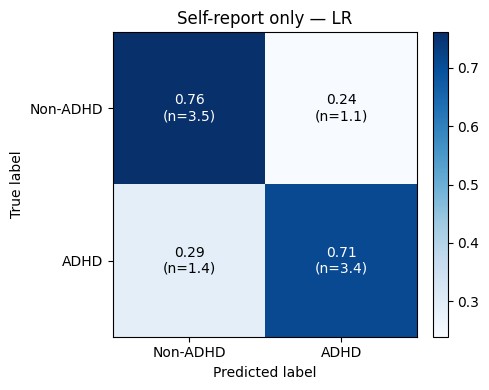


CPT + Activity [n = 79]
Model      AUC Accuracy Precision   Recall F1-Score      MCC
   RB     0.54     0.54      0.60     0.55     0.57     0.08
  MIN     0.50     0.56      0.56     1.00     0.71     0.00
  MAJ     0.50     0.56      0.56     1.00     0.71     0.00
   LR     0.76     0.66  **0.74**     0.67     0.68     0.35
   RF **0.78** **0.67**      0.72 **0.78** **0.71** **0.40**
  XGB     0.75     0.66      0.70     0.75     0.70     0.33
 LGBM     0.68     0.66      0.72     0.68     0.68     0.34


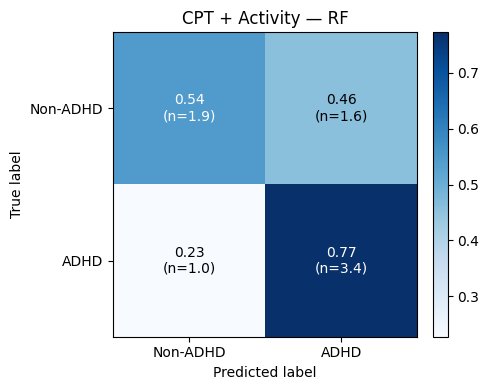


CPT + HRV [n = 75]
Model      AUC Accuracy Precision   Recall F1-Score      MCC
   RB     0.54     0.54      0.53     0.56     0.54     0.08
  MIN     0.50     0.49      0.49     1.00     0.66     0.00
  MAJ     0.50     0.51      0.00     0.00     0.00     0.00
   LR **0.80** **0.72**  **0.73** **0.72** **0.71** **0.45**
   RF     0.70     0.68      0.69     0.68     0.67     0.35
  XGB     0.67     0.67      0.72     0.61     0.65     0.34
 LGBM     0.63     0.61      0.63     0.63     0.62     0.20


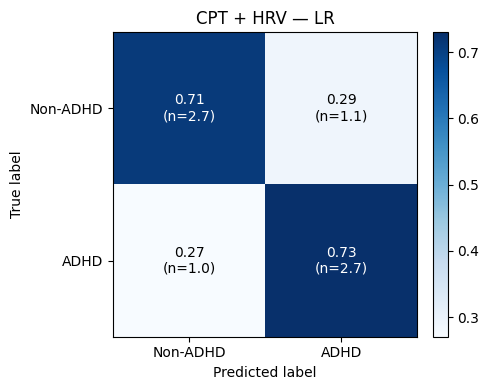


CPT + Self-report [n = 97]
Model      AUC Accuracy Precision   Recall F1-Score      MCC
   RB     0.53     0.52      0.55     0.44     0.49     0.05
  MIN     0.50     0.52      0.52     1.00     0.68     0.00
  MAJ     0.50     0.52      0.52     1.00     0.68     0.00
   LR **0.90** **0.81**  **0.84** **0.78** **0.80** **0.64**
   RF     0.86     0.76      0.80     0.76     0.76     0.54
  XGB     0.86     0.72      0.73     0.70     0.70     0.45
 LGBM     0.86     0.75      0.77     0.76     0.76     0.52


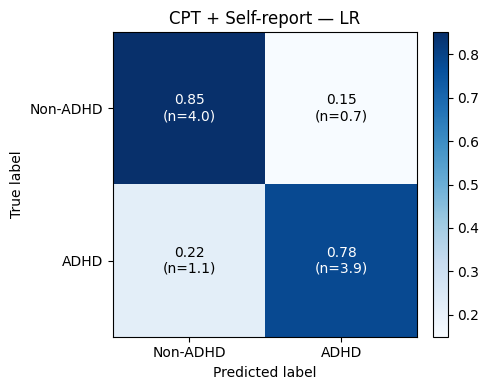


CPT + Act + HRV [n = 64]
Model      AUC Accuracy Precision   Recall F1-Score      MCC
   RB     0.60     0.60      0.61     0.63     0.62     0.21
  MIN     0.50     0.51      0.51     1.00     0.68     0.00
  MAJ     0.50     0.51      0.51     1.00     0.68     0.00
   LR     0.67 **0.64**      0.66     0.67 **0.65** **0.29**
   RF **0.72**     0.63  **0.66**     0.67     0.64     0.29
  XGB     0.71     0.63      0.59 **0.71**     0.63     0.27
 LGBM     0.66     0.61      0.55     0.64     0.59     0.24


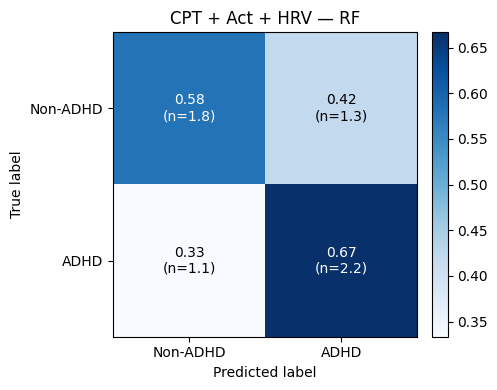


All modalities [n = 64]
Model      AUC Accuracy Precision   Recall F1-Score      MCC
   RB     0.60     0.60      0.61     0.63     0.62     0.21
  MIN     0.50     0.51      0.51     1.00     0.68     0.00
  MAJ     0.50     0.51      0.51     1.00     0.68     0.00
   LR     0.77     0.65      0.68     0.67     0.67     0.32
   RF     0.73     0.70      0.72     0.70     0.71     0.41
  XGB **0.79**     0.69      0.65     0.67     0.65     0.38
 LGBM     0.73 **0.71**  **0.73** **0.73** **0.71** **0.43**


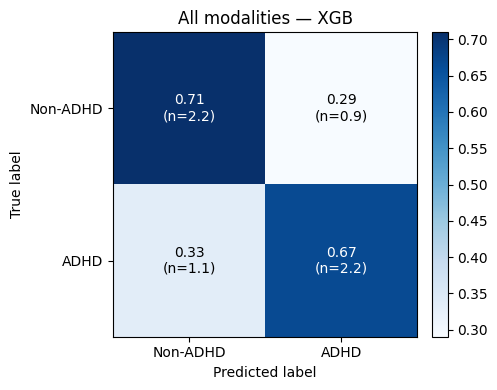

In [16]:
MODALITY_BLOCKS = {
    'CPT only':          cpt_avail,
    'Activity only':     act_avail,
    'HRV only':          hrv_avail,
    'Self-report only':  self_avail,
    'CPT + Activity':    cpt_avail + act_avail,
    'CPT + HRV':         cpt_avail + hrv_avail,
    'CPT + Self-report': cpt_avail + self_avail,
    'CPT + Act + HRV':   cpt_avail + act_avail + hrv_avail,
    'All modalities':    cpt_avail + act_avail + hrv_avail + self_avail,
}

for block_name, feat_list in MODALITY_BLOCKS.items():
    id_set = MODALITY_ID_SETS.get(block_name, ids_all)
    sub = build_block_df(feat_list, id_set)
    avail = [f for f in feat_list if f in sub.columns]
    if len(avail) < 2:
        continue

    sub = sub[avail + ['ADHD']].dropna(subset=avail[:2]).copy()
    X = sub[avail].values
    y = sub['ADHD'].astype(int).values

    if y.sum() < 5 or (y == 0).sum() < 5:
        continue

    print(f'\n{"="*80}')
    print(f'{block_name} [n = {len(id_set)}]')
    print(f'{"="*80}')

    results, cm_store = evaluate_models_10fold(X, y)
    print(format_results_table(results).to_string(index=False))

    main_results = results[~results['Model'].isin(['RB', 'MIN', 'MAJ'])].copy()
    best_model = main_results.sort_values(['AUC', 'F1-Score', 'MCC'], ascending=False).iloc[0]['Model']
    plot_avg_confusion_matrix(cm_store[best_model], title=f'{block_name} — {best_model}')

### 2.2 For each CPT feature individually, does the ADHD group differ from the non-ADHD group?

1. Mann-Whitney U over t-test
- tests whether two groups differ in distribution | “Is there any difference?”
- Why Mann-Whitney U (not t-test)?
- - CPT-II scores are heavily right-skewed in clinical samples — normality fails; Mann-Whitney tests rank-order differences, which is robust to skew and outliers

2. Rank-biserial r over Cohen's d
- quantifies the magnitude and direction of that difference in a probabilistic
- effect size = “How big is the difference?”
- non-normal and potentially skewed

3. FDR (False Discovery Rate)
- corrects p-values as testing multi-modality features to control how many “significant” results are expected to be false positives (differences by randomness)
- “Can I trust that this is not noise across many tests?”

In [17]:
# ── 2.2 CPT feature-level Mann-Whitney audit ─────────────────────────────────
mw_rows = []
sub1 = df[cpt_avail + ['ADHD']].dropna(subset=cpt_avail[:2])
for feat in cpt_avail:
    g1 = sub1.loc[sub1['ADHD']==1, feat].dropna()
    g0 = sub1.loc[sub1['ADHD']==0, feat].dropna()
    if len(g1)<3 or len(g0)<3: continue
    stat, p = mannwhitneyu(g1, g0, alternative='two-sided')
    # r = 1 --> a always higher, -1 --> a lower
    r_rb = 2*stat/(len(g1)*len(g0)) - 1
    mw_rows.append({'feature': feat, 'r_rb': r_rb, 'p': p,
                    'direction': '↑ADHD' if r_rb>0 else '↓ADHD'})

df_mw = pd.DataFrame(mw_rows)
if len(df_mw):
    df_mw['p_fdr'] = smm.multipletests(df_mw['p'], method='fdr_bh')[1]
    df_mw['sig'] = df_mw['p_fdr'].apply(lambda p: '**' if p<0.01 else ('*' if p<0.05 else ''))
    print(f"{'Feature':25s} {'r_rb':>7s} {'p_raw':>8s} {'p_fdr':>8s}  dir   sig")
    for _, r in df_mw.iterrows():
        print(f"{r['feature'][:25]:25s} {r['r_rb']:7.3f} {r['p']:8.4f} {r['p_fdr']:8.4f}  {r['direction']:7s} {r['sig']}")

Feature                      r_rb    p_raw    p_fdr  dir   sig
Raw Score Omissions         0.417   0.0039   0.0078  ↑ADHD   **
Raw Score Commissions       0.505   0.0005   0.0031  ↑ADHD   **
Raw Score HitRT            -0.271   0.0638   0.0956  ↓ADHD   
Raw Score HitSE             0.445   0.0023   0.0069  ↑ADHD   **
Raw Score VarSE             0.511   0.0005   0.0031  ↑ADHD   **
Raw Score DPrime           -0.433   0.0030   0.0072  ↓ADHD   **
Raw Score Beta              0.230   0.1160   0.1547  ↑ADHD   
Raw Score Perseverations    0.405   0.0012   0.0047  ↑ADHD   **
Raw Score HitRTBlock        0.218   0.1359   0.1631  ↑ADHD   
Raw Score HitSEBlock        0.208   0.1545   0.1685  ↑ADHD   
Raw Score HitRTIsi          0.331   0.0232   0.0398  ↑ADHD   *
Raw Score HitSEIsi          0.091   0.5366   0.5366  ↑ADHD   


### [Results] Can the CPT-II features discriminate ADHD from non-ADHD psychiatric controls?
- AUC = 0.802 > 0.8 = GOOD discriminative ability
- Accuracy = 73.2%; Balanced Accuracy = 73.3% = GOOD
- p = 0.002 < 0.05 = GOOD Permutation testing confirmed statistical significance

- r_rb = |effect size| > 0.5 = large effect, well-seperate
- ADHD group shows:
- - ↑ omission errors → inattentiveness
- - ↑ commission errors → impulsivity
- - ↑ RT variability (HitSE, VarSE) → unstable attention
- - ↓ d′ → poor signal detection ability [not able to diff. target & non-target/noise]
- - ↑ preservation -> poor inhibition/impulsive (respond tooo quick)

✅ Classic ADHD cognitive profile fully replicated

- - ** ↓ RT → ADHD responds faster, might be impulsive? -- high preservation [not significant]** -- other study on this dataset shows adult adhd less hyperactive/impulsive subtype
- - ↑ Beta → ADHD responds more cautious style/ conservative

### 2.3 Incremental Modality Value: What Does Each Modality Add Beyond CPT?

- Test every combination: which modality **adds beyond CPT-II**.

In [18]:
# ── 2.3 Incremental modality value ───────────────────────────────────────────
mod_results = {}
rows_mod = []
print(f'{"Block":15s} {"n":>5s} {"AUC":>6s} {"Acc":>6s} {"BalAcc":>7s} '
      f'{"Prec":>6s} {"Recall":>7s} {"F1":>6s} {"MCC":>6s} {"perm_p":>7s} sig')

for name, feat_list in MODALITY_BLOCKS.items():
    id_set = MODALITY_ID_SETS.get(name, ids_all)
    sub = build_block_df(feat_list, id_set)
    avail = [f for f in feat_list if f in sub.columns]
    if not avail: continue

    sub = sub[avail + ['ADHD']].dropna(subset=avail[:2])
    X, y = sub[avail].values, sub['ADHD'].values
    if y.sum() < 5 or (y == 0).sum() < 5: continue

    res = cv_metrics_10fold(X, y)
    mod_results[name] = res
    sig = '✅' if res['perm_p'] < 0.05 else ''

    rows_mod.append({
        'Block': name,
        'n': len(y),
        'AUC': res['auc'],
        'Accuracy': res['accuracy'],
        'Balanced Acc': res['bacc'],
        'Precision': res['precision'],
        'Recall': res['recall'],
        'F1': res['f1'],
        'MCC': res['mcc'],
        'perm_p': res['perm_p'],
        'Sig': sig,
    })

# ── Summary table sorted by AUC (primary threshold-independent) and Balanced Accuracy (secondary) ──
df_mod_summary = pd.DataFrame(rows_mod).sort_values(['AUC', 'Balanced Acc', 'F1'], ascending=False).reset_index(drop=True)
display(df_mod_summary.round({'AUC': 4, 'Accuracy': 4, 'Balanced Acc': 4,
    'Precision': 4, 'Recall': 4, 'F1': 4, 'MCC': 4, 'perm_p': 4,}))

best = df_mod_summary.iloc[0]
print(f'\n★ Best block: {best["Block"]}')
print(f'AUC={best["AUC"]:.4f} | Acc={best["Accuracy"]:.4f} | '
      f'BalAcc={best["Balanced Acc"]:.4f} | F1={best["F1"]:.4f} | MCC={best["MCC"]:.4f}')

Block               n    AUC    Acc  BalAcc   Prec  Recall     F1    MCC  perm_p sig


,Block,n,AUC,Accuracy,Balanced Acc,Precision,Recall,F1,MCC,perm_p,Sig
0,CPT + Self-report,97,0.8945,0.8144,0.8155,0.8478,0.7800,0.8125,0.6316,0.0020,✅
1,Self-report only,94,0.8510,0.7340,0.7346,0.7556,0.7083,0.7312,0.4695,0.0020,✅
2,CPT only,97,0.8004,0.7320,0.7336,0.7727,0.6800,0.7234,0.4690,0.0020,✅
3,CPT + HRV,75,0.7852,0.7200,0.7201,0.7105,0.7297,0.7200,0.4403,0.0020,✅
4,All modalities,64,0.7498,0.6562,0.6559,0.6667,0.6667,0.6667,0.3118,0.0060,✅
5,CPT + Activity,79,0.7058,0.6582,0.6581,0.7073,0.6591,0.6824,0.3144,0.0020,✅
6,CPT + Act + HRV,64,0.6706,0.6406,0.6398,0.6471,0.6667,0.6567,0.2800,0.0439,✅
7,Activity only,85,0.5278,0.5412,0.5375,0.5625,0.6000,0.5806,0.0755,0.6108,
8,HRV only,80,0.3778,0.4375,0.4330,0.3939,0.3421,0.3662,-0.1360,0.7984,



★ Best block: CPT + Self-report
AUC=0.8945 | Acc=0.8144 | BalAcc=0.8155 | F1=0.8125 | MCC=0.6316


### Results interpretation — Incremental Modality Value

- CPT + Self-report fusion dominates: AUC=0.894, Balanced Accuracy=0.816, MCC=0.632 — all metrics well above the paper's reported best of 72% accuracy

- HRV performs below chance (AUC=0.378, MCC=−0.136): Model sees ADHD sometimes higher/variable HR (possible for hyperactive/impulsive); non-ADHD lower (possible for anxiety, stress, depression) -- flipping the expected direction and causing the classifier to invert. The negative MCC confirms systematic inversion.

- Activity alone is near-chance (AUC=0.528): Motor dysregulation is transdiagnostic


---
## Phase 3 — 3-Way Supervised Multiclass Classification: ADD vs ADHD vs Non-ADHD

**Why 3-class instead of binary?**
The binary ADHD/Control split hides clinically meaningful heterogeneity.
ADD (inattentive subtype) is diagnostically distinct from combined ADHD — it presents with
*high omissions* (inattention) but *low commissions* (no impulsivity). Lumping ADD into the
ADHD class masks this profile and inflates binary AUC by including easier-to-classify ADD cases.

**Design choices:**

| Choice | Rationale |
|--------|-----------|
| **Logistic Regression OvR** | Extends naturally to multiple classes; interpretable coefficients |
| **Macro-averaged F1** | Each class weighted equally — critical when ADD (n≈8) is much smaller than ADHD (n≈43) |
| **Macro-AUC (OvO)** | One-vs-one AUC on all class pairs — the standard for imbalanced multiclass |
| **Balanced class_weight** | Prevents the model from ignoring ADD due to class imbalance |
| **Stratified 10-fold** | Guarantees ADD appears in training folds |

**Why not weighted F1?**
Weighted F1 gives large classes disproportionate weight and would let the model ignore ADD entirely
while still scoring well. Macro F1 exposes this behaviour.


In [19]:
# Three classes: ADD | ADHD | Non-ADHD
# CLASS_ORDER and CLASS_MAP define the label encoding for all 3-way classification.
# Per-modality data is built inside the loop in cell 35 using build_block_df.
CLASS_ORDER = ['Non-ADHD', 'ADHD', 'ADD']
CLASS_MAP   = {c: i for i, c in enumerate(CLASS_ORDER)}

# Print class distribution across all patients with a primary_dx label
dx_counts = df_pat['primary_dx'].value_counts()
print('3-class distribution (full cohort):')
for cls in CLASS_ORDER:
    print(f'  {cls}: n={dx_counts.get(cls, 0)}')

3-class distribution (full cohort):
  Non-ADHD: n=52
  ADHD: n=28
  ADD: n=23


In [20]:
# ── Multiclass CV function ───────────────────────────────────────────────
def cv_multiclass(X, y, class_names, n_splits=5):
    n_classes = len(np.unique(y))
    if n_classes < 3 or len(X) < 15: return {}

    clf = make_pipe(LogisticRegression(C=0.1, max_iter=2000, random_state=SEED, class_weight='balanced'))
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    pred = cross_val_predict(clf, X, y, cv=cv, method='predict')
    proba = cross_val_predict(clf, X, y, cv=cv, method='predict_proba')

    macro_f1 = f1_score(y, pred, average='macro')
    macro_auc = roc_auc_score(y, proba, multi_class='ovr', average='macro')
    bacc = balanced_accuracy_score(y, pred)
    cm = confusion_matrix(y, pred)
    per_class_recall = {class_names[i]: cm[i,i]/cm[i].sum() if cm[i].sum()>0 else 0
                        for i in range(len(class_names))}

    # Permutation test (macro-F1) -- imbalanced dataset contribute equally
    _, _, perm_p = permutation_test_score(clf, X, y, cv=cv, scoring='f1_macro',
                                          n_permutations=300, random_state=SEED)
    return {
        'macro_f1': macro_f1, 'macro_auc': macro_auc, 'bacc': bacc,
        'cm': cm, 'per_class_recall': per_class_recall,
        'perm_p': perm_p, 'pred': pred, 'proba': proba, 'y_true': y
    }

### 3.1 3-way classification across modality combinations

In [21]:
# ── 3-Class Incremental modality value ─────────────────────────────────────
results_3c = {}
rows_3c = []

print(f'{"Modality":25s} {"n":>5s} {"MacroF1":>8s} {"MacroAUC":>9s} '
      f'{"BalAcc":>7s} {"ADHD":>6s} {"ADD":>6s} {"NonADHD":>8s} {"perm_p":>7s} sig')

for name, feat_list in MODALITY_BLOCKS.items():
    id_set = MODALITY_ID_SETS.get(name, ids_all)
    sub3 = build_block_df(feat_list, id_set)

    avail = [f for f in feat_list if f in sub3.columns]
    if not avail: continue

    sub3 = sub3[sub3['primary_dx'].isin(CLASS_ORDER)].dropna(subset=avail[:2]).copy()
    y3_str = sub3['primary_dx'].values
    y3 = np.array([CLASS_MAP[c] for c in y3_str])
    if len(np.unique(y3)) < 3: continue
    X3 = sub3[avail].values

    # CV setup
    n_min = pd.Series(y3).value_counts().min()
    n_splits = max(2, min(5, n_min))

    res = cv_multiclass(X3, y3, CLASS_ORDER, n_splits=n_splits)
    if not res: continue

    results_3c[name] = res
    r = res['per_class_recall']
    sig = '✅' if res['perm_p'] < 0.05 else ''

    rows_3c.append({
        'Modality': name,
        'n': len(y3),
        'MacroF1': res['macro_f1'],
        'MacroAUC': res['macro_auc'],
        'Balanced Acc': res['bacc'],
        'ADHD Recall': r.get('ADHD', 0),
        'ADD Recall': r.get('ADD', 0),
        'Non-ADHD Recall': r.get('Non-ADHD', 0),
        'perm_p': res['perm_p'],
        'Sig': sig,
    })

df_3c_summary = pd.DataFrame(rows_3c).sort_values(['MacroF1', 'MacroAUC', 'Balanced Acc'], ascending=False).reset_index(drop=True)
display(df_3c_summary.round({'MacroF1': 4, 'MacroAUC': 4, 'Balanced Acc': 4,
    'ADHD Recall': 4, 'ADD Recall': 4, 'Non-ADHD Recall': 4, 'perm_p': 4,}))

best = df_3c_summary.iloc[0]
print(f'\n★ Best modality: {best["Modality"]}')
print(f'Macro-F1={best["MacroF1"]:.4f} | Macro-AUC={best["MacroAUC"]:.4f} | '
      f'BalAcc={best["Balanced Acc"]:.4f}')
print(f'Per-class recall → ADHD={best["ADHD Recall"]:.3f}, '
      f'ADD={best["ADD Recall"]:.3f}, Non-ADHD={best["Non-ADHD Recall"]:.3f}')

Modality                      n  MacroF1  MacroAUC  BalAcc   ADHD    ADD  NonADHD  perm_p sig


,Modality,n,MacroF1,MacroAUC,Balanced Acc,ADHD Recall,ADD Recall,Non-ADHD Recall,perm_p,Sig
0,Self-report only,94,0.6315,0.8043,0.6435,0.8000,0.3913,0.7391,0.0033,✅
1,CPT + Self-report,97,0.6197,0.8103,0.6175,0.6296,0.4783,0.7447,0.0033,✅
2,All modalities,64,0.5390,0.7296,0.5353,0.5000,0.4286,0.6774,0.0033,✅
3,CPT + Activity,79,0.5032,0.6934,0.5037,0.4762,0.4348,0.6000,0.0033,✅
4,CPT only,97,0.4883,0.7055,0.4858,0.4074,0.3478,0.7021,0.0066,✅
5,CPT + Act + HRV,64,0.4837,0.6474,0.4872,0.5000,0.3810,0.5806,0.0133,✅
6,Activity only,85,0.4560,0.6240,0.4678,0.5000,0.4783,0.4250,0.0299,✅
7,CPT + HRV,75,0.4440,0.6364,0.4417,0.3125,0.3810,0.6316,0.0664,
8,HRV only,80,0.2963,0.4621,0.3119,0.4118,0.1905,0.3333,0.6179,



★ Best modality: Self-report only
Macro-F1=0.6315 | Macro-AUC=0.8043 | BalAcc=0.6435
Per-class recall → ADHD=0.800, ADD=0.391, Non-ADHD=0.739


### Results

- ADD is the bottleneck for all models: The best model (Self-report) achieves ADHD recall=0.80 and Non-ADHD recall=0.74, but ADD recall=0.39 -- ADD presents on a continuum with both ADHD and non-ADHD, without the clear hyperactivity signal

- Macro-AUC stays high even where macro-F1 drops: e.g., CPT only has macro-F1=0.488 but macro-AUC=0.706.
- - Model can rank patients correctly (e.g., ADHD tend to get higher scores than others) but struggles to make clean category decisions (when forced to assign discrete labels, it misclassifies many cases)

### 3.2 confusion matrix + per-class recall:
- "When the model is wrong, how is it wrong?”
- Due to class imbalance (ADD is small), Macro-F1 alone can hide which class is failing.
supervised classification, so:

Ground truth (correct) = y_true (from primary_dx)

Prediction = res_best['pred']

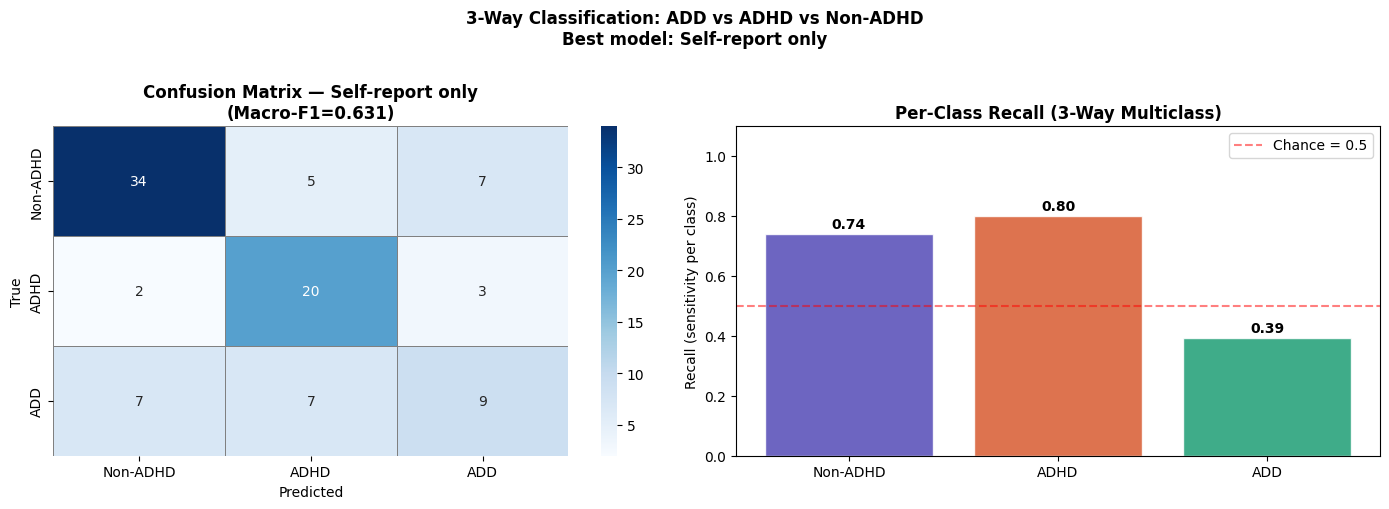


--- CLASSIFICATION REPORT (Self-report only) ---
              precision    recall  f1-score   support

    Non-ADHD       0.79      0.74      0.76        46
        ADHD       0.62      0.80      0.70        25
         ADD       0.47      0.39      0.43        23

    accuracy                           0.67        94
   macro avg       0.63      0.64      0.63        94
weighted avg       0.67      0.67      0.67        94



In [22]:
best_mod = max(results_3c, key=lambda k: results_3c[k]['macro_f1'])
res_best = results_3c[best_mod]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = res_best['cm']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER,
            linewidths=0.5, linecolor='gray')
axes[0].set_title( f"Confusion Matrix — {best_mod}\n(Macro-F1={res_best['macro_f1']:.3f})", fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

# Per-class recall bar chart
recalls = [res_best['per_class_recall'][c] for c in CLASS_ORDER]
colors_3c = ['#534AB7', '#D85A30', '#1D9E75']
bars = axes[1].bar(CLASS_ORDER, recalls, color=colors_3c, edgecolor='white', alpha=0.85)
axes[1].axhline(0.5, linestyle='--', color='red', alpha=0.5, label='Chance = 0.5')
for bar, val in zip(bars, recalls):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', fontweight='bold')
axes[1].set_ylabel('Recall (sensitivity per class)')
axes[1].set_title('Per-Class Recall (3-Way Multiclass)', fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].legend()
plt.suptitle(f'3-Way Classification: ADD vs ADHD vs Non-ADHD\nBest model: {best_mod}', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'\n--- CLASSIFICATION REPORT ({best_mod}) ---')
y3_true = res_best['y_true']
print(classification_report(y3_true, res_best['pred'], target_names=CLASS_ORDER, zero_division=0))

ADD (23 total) -- Only 11 correct; 7 → confused with Non-ADHD; 5 → confused with ADHD

👉 ADD is poorly separated: model cannot distinguish it well from either group

---
## Phase 4 — CPT-II Profile Clustering → Cognitive Subtypes

**Key insight:** Instead of predicting ADHD from features, we *cluster in CPT-II score space*
to define cognitive subtypes directly from the clinical gold standard.

**Design choices:**

| Choice | Rationale |
|--------|-----------|
| **T-scores for clustering** | All 5 CPT-II dimensions on the same scale (mean=50, SD=10) — Euclidean K-Means needs comparable magnitudes |
| **K-Means (primary)** | Most reproducible with fixed seed; fast for small n |
| **Agglomerative (sensitivity)** | Hierarchical — no assumption of spherical clusters; used to validate K-Means |
| **Silhouette** | Global cluster quality: are points better matched to their own cluster than neighbours? |
| **Davies-Bouldin** | Cluster compactness + separation ratio — lower is better |
| **Kneelocator** | Data-driven elbow detection — avoids subjective reading of the elbow plot |
| **Permutation test on silhouette** | Null distribution of silhouette from shuffled labels — tests if structure exceeds chance |


In [23]:
df_cpt_cl = df_cpt[CPT_CLUSTER_TARGETS]
df_cpt_cl.index = df_cpt_cl.index.astype(str)
df_pat.index = df_pat.index.astype(str)

pids_cpt = df_cpt_cl.index[df_cpt_cl.index.isin(df_pat.index)].tolist()
df_cpt_cl = df_cpt_cl.loc[pids_cpt]

X_cpt = StandardScaler().fit_transform(df_cpt_cl.values)
y_cpt = df_pat.loc[pids_cpt, 'ADHD'].values.astype(int)
y_add = df_pat.loc[pids_cpt, 'ADD'].fillna(0).values.astype(int) if 'ADD' in df_pat.columns else np.zeros(len(pids_cpt), dtype=int)
dx_all = df_pat.loc[pids_cpt, 'primary_dx'].values

print(f'CPT-II profile matrix: {X_cpt.shape}')
print(f'ADHD={y_cpt.sum()} | Control={(y_cpt==0).sum()} | ADD={y_add.sum()}')

CPT-II profile matrix: (97, 13)
ADHD=50 | Control=47 | ADD=23


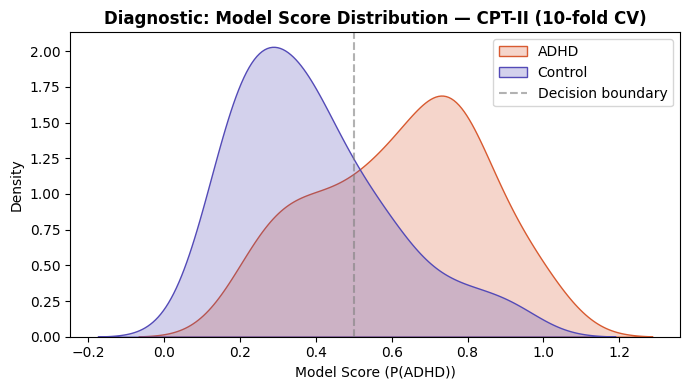

ADHD    — mean=0.623, median=0.649
Control — mean=0.390, median=0.347


In [24]:
# ── Diagnostic: model score distribution (CPT-only, 10-fold CV) ──────────────
_clf_diag = make_pipe(LogisticRegression(C=0.1, max_iter=1000, random_state=SEED, class_weight='balanced'))
_X_diag   = StandardScaler().fit_transform(
    SimpleImputer(strategy='median').fit_transform(
        df_cpt_cl.loc[pids_cpt, CPT_CLUSTER_TARGETS]))
_y_diag   = df_pat.loc[pids_cpt, 'ADHD'].values.astype(int)

_proba_diag = cross_val_predict(
    _clf_diag, _X_diag, _y_diag,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED),
    method='predict_proba'
)[:, 1]

fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(_proba_diag[_y_diag == 1], label='ADHD', fill=True, ax=ax, color=PALETTE['ADHD'])
sns.kdeplot(_proba_diag[_y_diag == 0], label='Control', fill=True, ax=ax, color=PALETTE['Control'])
ax.axvline(0.5, linestyle='--', color='gray', alpha=0.6, label='Decision boundary')
ax.set_xlabel('Model Score (P(ADHD))')
ax.set_title('Diagnostic: Model Score Distribution — CPT-II (10-fold CV)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'ADHD    — mean={_proba_diag[_y_diag==1].mean():.3f}, '
      f'median={np.median(_proba_diag[_y_diag==1]):.3f}')
print(f'Control — mean={_proba_diag[_y_diag==0].mean():.3f}, '
      f'median={np.median(_proba_diag[_y_diag==0]):.3f}')


- model assigns higher probabilities to ADHD than controls (mean: 0.623 vs 0.390), showing good directional discrimination.
- The two distributions are clearly shifted but still overlap, meaning the model separates groups reasonably well but not perfectly.
- decision boundary at 0.5 cuts through the overlap → both false positives and false negatives exist

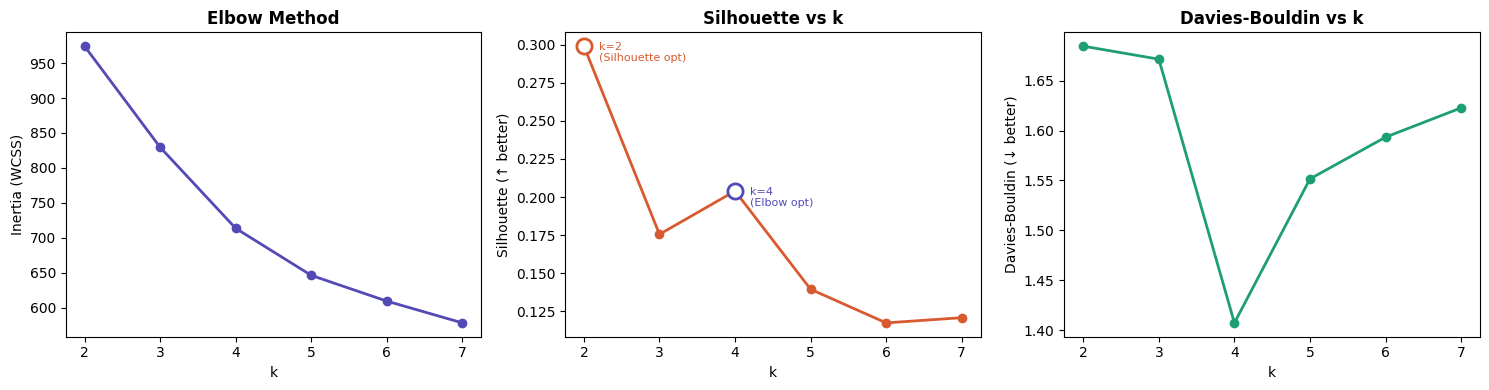

Best k by silhouette: 2 | By elbow: 4
Silhouette at k=2: 0.2990


In [25]:
# ── 4.1 Optimal k selection ───────────────────────────────────────────────────
K_RANGE = range(2, 8)
sil_scores, db_scores, inertias = [], [], []

for k in K_RANGE:
    km  = KMeans(n_clusters=k, random_state=SEED, n_init=30)
    lbl = km.fit_predict(X_cpt)
    sil_scores.append(silhouette_score(X_cpt, lbl))
    db_scores.append(davies_bouldin_score(X_cpt, lbl))
    km.fit(X_cpt)
    inertias.append(km.inertia_)

BEST_K_sil = list(K_RANGE)[np.argmax(sil_scores)]
knee = KneeLocator(list(K_RANGE), inertias, curve='convex', direction='decreasing')
BEST_K_elbow = knee.knee

# Annotated plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, scores, ylabel, color, title in [
    (axes[0], inertias,   'Inertia (WCSS)', '#534AB7', 'Elbow Method'),
    (axes[1], sil_scores, 'Silhouette (↑ better)', '#D85A30', 'Silhouette vs k'),
    (axes[2], db_scores,  'Davies-Bouldin (↓ better)','#1D9E75','Davies-Bouldin vs k'),
]:
    ax.plot(list(K_RANGE), scores, 'o-', color=color, linewidth=2)
    ax.set_xlabel('k'); ax.set_ylabel(ylabel); ax.set_title(title, fontweight='bold')

# Mark chosen k
for best, label, col in [(BEST_K_sil, 'Silhouette opt', '#D85A30'), (BEST_K_elbow, 'Elbow opt', '#534AB7')]:
    idx = best - list(K_RANGE)[0]
    axes[1].scatter([best], [sil_scores[idx]], s=120, facecolor='white',
                    edgecolors=col, linewidths=2, zorder=5)
    axes[1].annotate(f'k={best}\n({label})', xy=(best, sil_scores[idx]),
                      xytext=(best+0.2, sil_scores[idx]-0.01), fontsize=8, color=col)
plt.tight_layout();
plt.show()
print(f'Best k by silhouette: {BEST_K_sil} | By elbow: {BEST_K_elbow}')
print(f'Silhouette at k={BEST_K_sil}: {sil_scores[BEST_K_sil - list(K_RANGE)[0]]:.4f}')

In [26]:
# ── Clustering Helper Functions (single source of truth) ─────────────────────
def relabel_by_adhd(labels, y_adhd):
    """Relabel clusters: 0 = lowest ADHD%, k-1 = highest ADHD%."""
    rates   = {c: y_adhd[labels == c].mean() for c in np.unique(labels)}
    order   = sorted(rates, key=rates.get)
    mapping = {old: new for new, old in enumerate(order)}
    return np.array([mapping[c] for c in labels])

def ordered_sizes(labels, k):
    return (pd.Series(labels).value_counts()
            .reindex(range(k), fill_value=0).astype(int).to_dict())

def ordered_adhd_rates(labels, y_adhd, k):
    df_tmp = pd.DataFrame({'cluster': labels, 'ADHD': y_adhd})
    return (df_tmp.groupby('cluster')['ADHD']
            .mean().reindex(range(k), fill_value=np.nan).round(2).to_dict())

def select_k(X, k_range=range(2, 7), seed=SEED):
    inertias, sils, dbs = [], [], []
    for k in k_range:
        km   = KMeans(n_clusters=k, random_state=seed, n_init=30)
        labs = km.fit_predict(X)
        inertias.append(km.inertia_)
        sils.append(silhouette_score(X, labs))
        dbs.append(davies_bouldin_score(X, labs))
    best_k = list(k_range)[int(np.argmax(sils))]
    return best_k, inertias, sils, dbs

In [27]:
def fit_cluster_labels(X, y_adhd, algo='kmeans', k=2, seed=SEED):
    if algo == 'kmeans':
        model = KMeans(n_clusters=k, random_state=seed, n_init=30)
        labels = model.fit_predict(X)
    elif algo == 'agg':
        model = AgglomerativeClustering(n_clusters=k, linkage='ward')
        labels = model.fit_predict(X)
    elif algo == 'gmm':
        model = GaussianMixture(n_components=k, random_state=seed, n_init=10)
        labels = model.fit_predict(X)
    else:
        raise ValueError(f'Unknown algo: {algo}')

    labels = relabel_by_adhd(labels, y_adhd)
    return labels

In [28]:
def run_clustering(X_full, y_adhd, y_add, pids, label='', algo='kmeans', fixed_k=None, k_range=range(2, 7), seed=SEED):
    # choose k
    if fixed_k is None:
        if algo != 'kmeans': raise ValueError("Automatic k selection is currently implemented only for algo='kmeans'.")
        k_range = list(k_range)
        best_k, inertias, sils, dbs = select_k(X_full, k_range, seed)
    else:
        best_k = fixed_k
        inertias, sils, dbs = None, None, None

    # fit labels
    labs = fit_cluster_labels(X_full, y_adhd, algo=algo, k=best_k, seed=seed)

    # metrics
    sil = silhouette_score(X_full, labs)
    db = davies_bouldin_score(X_full, labs)
    ari = adjusted_rand_score(y_adhd, labs)
    nmi = normalized_mutual_info_score(y_adhd, labs)
    ari_add = adjusted_rand_score(y_add, labs) if y_add.sum() > 0 else np.nan

    ct = pd.crosstab(labs, y_adhd)
    chi2_stat, p_chi2, _, _ = chi2_contingency(ct)

    n_vis = min(2, X_full.shape[0] - 1, X_full.shape[1])
    pca2 = PCA(n_components=n_vis, random_state=seed)
    emb2 = pca2.fit_transform(X_full)
    vexp = pca2.explained_variance_ratio_ * 100

    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

    # optional k-selection plots
    if inertias is not None:
        axes[0].plot(k_range, inertias, 'o-', color='#534AB7', linewidth=2)
        axes[0].set_xlabel('k')
        axes[0].set_ylabel('Inertia')
        axes[0].set_title('Elbow', fontweight='bold')

        axes[1].plot(k_range, sils, 'o-', color='#D85A30', linewidth=2)
        axes[1].axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
        axes[1].axhline(0.25, color='gray', linestyle=':', alpha=0.5)
        axes[1].set_xlabel('k')
        axes[1].set_ylabel('Silhouette')
        axes[1].set_title('Silhouette', fontweight='bold')
        axes[1].legend()

    # Panel 3: cluster labels
    for c in sorted(np.unique(labs)):
        m = labs == c
        adhd_pct = 100.0 * y_adhd[m].mean() if m.sum() > 0 else 0.0
        axes[2].scatter(
            emb2[m, 0], emb2[m, 1],
            s=60, alpha=0.85,
            color=PALETTE.get(f'C{c}', plt.cm.tab10(c)),
            edgecolors='white', linewidths=0.5,
            label=f'C{c} n={m.sum()} ADHD={adhd_pct:.0f}%'
        )

    axes[2].set_xlabel(f'PC1 ({vexp[0]:.1f}%)' if len(vexp) > 0 else 'PC1')
    axes[2].set_ylabel(f'PC2 ({vexp[1]:.1f}%)' if len(vexp) > 1 else 'PC2')
    axes[2].set_title('Clusters', fontweight='bold')
    axes[2].legend(fontsize=7)

    # Panel 4: ground truth
    for dx, color, marker, lbl in [
        (0, PALETTE['Control'], '^', 'Control'),
        (1, PALETTE['ADHD'], 'o', 'ADHD')
    ]:
        m = y_adhd == dx
        axes[3].scatter(
            emb2[m, 0], emb2[m, 1],
            s=75, alpha=0.95, c=color, marker=marker,
            edgecolors='white', linewidths=0.5, label=lbl
        )

    if y_add.sum() > 0:
        m_add = y_add == 1
        axes[3].scatter(
            emb2[m_add, 0], emb2[m_add, 1],
            s=55, alpha=1.0, c=PALETTE['ADD'], marker='s',
            edgecolors='black', linewidths=0.5,
            label=f'ADD (n={y_add.sum()})'
        )

    axes[3].set_xlabel(f'PC1 ({vexp[0]:.1f}%)' if len(vexp) > 0 else 'PC1')
    axes[3].set_ylabel(f'PC2 ({vexp[1]:.1f}%)' if len(vexp) > 1 else 'PC2')
    axes[3].set_title('Ground Truth', fontweight='bold')
    axes[3].legend(fontsize=7)

    plt.suptitle(f'Clustering — {label} ({algo}, k={best_k})', fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

    # print summary
    print(f'\n{"─"*55}')
    print(f'  {label}  |  algo={algo}  k={best_k}  N={len(X_full)}  features={X_full.shape[1]}')
    print(f'  Silhouette={sil:.4f}  DB={db:.4f}')
    print(f'  ARI(ADHD)={ari:.4f}  NMI={nmi:.4f}  χ²p={p_chi2:.4f}')
    if not np.isnan(ari_add):
        print(f'  ARI(ADD)={ari_add:.4f}')

    print('  ADHD% per cluster:')
    for k_val in range(best_k):
        m = labs == k_val
        print(
            f'    C{k_val}: n={m.sum():3d}  ADHD={y_adhd[m].sum():3d} '
            f'({100*y_adhd[m].mean():.0f}%)  ADD={y_add[m].sum():2d}'
        )

    return {
        'label': label,
        'algo': algo,
        'k': best_k,
        'labels': labs,
        'pids': [str(p) for p in pids],
        'silhouette': sil,
        'db': db,
        'ari_adhd': ari,
        'nmi_adhd': nmi,
        'ari_add': ari_add,
        'chi2_p': p_chi2,
        'y_adhd': y_adhd,
        'y_add': y_add,
        'emb2': emb2,
        'emb': emb2,   # alias for downstream cells
        'n': len(X_full),
    }

In [29]:
def run_clustering(X_full, y_adhd, y_add, pids, label='', algo='kmeans', fixed_k=None, k_range=range(2, 7), seed=SEED):
    # choose k
    if fixed_k is None:
        if algo != 'kmeans': raise ValueError("Automatic k selection is currently implemented only for algo='kmeans'.")
        k_range = list(k_range)
        _, inertias, sils, dbs = select_k(X_full, k_range, seed)

        # keep plotting all k (including 2), but choose best only among k > 2
        valid_idx = [i for i, k in enumerate(k_range) if k > 2]
        if len(valid_idx) == 0:
            raise ValueError("k_range must contain at least one k > 2.")

        best_i = max(valid_idx, key=lambda i: sils[i])
        best_k = k_range[best_i]
    else:
        best_k = fixed_k
        inertias, sils, dbs = None, None, None

    # fit labels
    labs = fit_cluster_labels(X_full, y_adhd, algo=algo, k=best_k, seed=seed)

    # metrics
    sil = silhouette_score(X_full, labs)
    db = davies_bouldin_score(X_full, labs)
    ari = adjusted_rand_score(y_adhd, labs)
    nmi = normalized_mutual_info_score(y_adhd, labs)
    ari_add = adjusted_rand_score(y_add, labs) if y_add.sum() > 0 else np.nan

    ct = pd.crosstab(labs, y_adhd)
    chi2_stat, p_chi2, _, _ = chi2_contingency(ct)

    n_vis = min(2, X_full.shape[0] - 1, X_full.shape[1])
    pca2 = PCA(n_components=n_vis, random_state=seed)
    emb2 = pca2.fit_transform(X_full)
    vexp = pca2.explained_variance_ratio_ * 100

    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

    # optional k-selection plots
    if inertias is not None:
        axes[0].plot(k_range, inertias, 'o-', color='#534AB7', linewidth=2)
        axes[0].set_xlabel('k')
        axes[0].set_ylabel('Inertia')
        axes[0].set_title('Elbow', fontweight='bold')

        axes[1].plot(k_range, sils, 'o-', color='#D85A30', linewidth=2)
        axes[1].axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
        axes[1].axhline(0.25, color='gray', linestyle=':', alpha=0.5)
        axes[1].set_xlabel('k')
        axes[1].set_ylabel('Silhouette')
        axes[1].set_title('Silhouette', fontweight='bold')
        axes[1].legend()

    # Panel 3: cluster labels
    for c in sorted(np.unique(labs)):
        m = labs == c
        adhd_pct = 100.0 * y_adhd[m].mean() if m.sum() > 0 else 0.0
        axes[2].scatter(
            emb2[m, 0], emb2[m, 1],
            s=60, alpha=0.85,
            color=PALETTE.get(f'C{c}', plt.cm.tab10(c)),
            edgecolors='white', linewidths=0.5,
            label=f'C{c} n={m.sum()} ADHD={adhd_pct:.0f}%'
        )

    axes[2].set_xlabel(f'PC1 ({vexp[0]:.1f}%)' if len(vexp) > 0 else 'PC1')
    axes[2].set_ylabel(f'PC2 ({vexp[1]:.1f}%)' if len(vexp) > 1 else 'PC2')
    axes[2].set_title('Clusters', fontweight='bold')
    axes[2].legend(fontsize=7)

    # Panel 4: ground truth
    for dx, color, marker, lbl in [
        (0, PALETTE['Control'], '^', 'Control'),
        (1, PALETTE['ADHD'], 'o', 'ADHD')
    ]:
        m = y_adhd == dx
        axes[3].scatter(
            emb2[m, 0], emb2[m, 1],
            s=75, alpha=0.95, c=color, marker=marker,
            edgecolors='white', linewidths=0.5, label=lbl
        )

    if y_add.sum() > 0:
        m_add = y_add == 1
        axes[3].scatter(
            emb2[m_add, 0], emb2[m_add, 1],
            s=55, alpha=1.0, c=PALETTE['ADD'], marker='s',
            edgecolors='black', linewidths=0.5,
            label=f'ADD (n={y_add.sum()})'
        )

    axes[3].set_xlabel(f'PC1 ({vexp[0]:.1f}%)' if len(vexp) > 0 else 'PC1')
    axes[3].set_ylabel(f'PC2 ({vexp[1]:.1f}%)' if len(vexp) > 1 else 'PC2')
    axes[3].set_title('Ground Truth', fontweight='bold')
    axes[3].legend(fontsize=7)

    plt.suptitle(f'Clustering — {label} ({algo}, k={best_k})', fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

    # print summary
    print(f'\n{"─"*55}')
    print(f'  {label}  |  algo={algo}  k={best_k}  N={len(X_full)}  features={X_full.shape[1]}')
    print(f'  Silhouette={sil:.4f}  DB={db:.4f}')
    print(f'  ARI(ADHD)={ari:.4f}  NMI={nmi:.4f}  χ²p={p_chi2:.4f}')
    if not np.isnan(ari_add):
        print(f'  ARI(ADD)={ari_add:.4f}')

    print('  ADHD% per cluster:')
    for k_val in range(best_k):
        m = labs == k_val
        print(
            f'    C{k_val}: n={m.sum():3d}  ADHD={y_adhd[m].sum():3d} '
            f'({100*y_adhd[m].mean():.0f}%)  ADD={y_add[m].sum():2d}'
        )

    return {
        'label': label,
        'algo': algo,
        'k': best_k,
        'labels': labs,
        'pids': [str(p) for p in pids],
        'silhouette': sil,
        'db': db,
        'ari_adhd': ari,
        'nmi_adhd': nmi,
        'ari_add': ari_add,
        'chi2_p': p_chi2,
        'y_adhd': y_adhd,
        'y_add': y_add,
        'emb2': emb2,
        'emb': emb2,   # alias for downstream cells
        'n': len(X_full),
    }

In [30]:
for k in range(2, 5):
    print(f'Algorithm comparison (k={k}):')
    for algo in [('kmeans'),('agg'),('gmm')]:
        lbl = fit_cluster_labels(X_cpt, y_cpt, algo=algo, k=k, seed=SEED)
        sil = silhouette_score(X_cpt, lbl)
        db  = davies_bouldin_score(X_cpt, lbl)

        print(f'  {algo:16s}: silhouette={sil:.4f}  DB={db:.4f}  '
            f'sizes={ordered_sizes(lbl, k)}  ADHD%={ordered_adhd_rates(lbl, y_cpt, k)}')

Algorithm comparison (k=2):
  kmeans          : silhouette=0.2990  DB=1.6845  sizes={0: 72, 1: 25}  ADHD%={0: 0.4, 1: 0.84}
  agg             : silhouette=0.2507  DB=1.8022  sizes={0: 65, 1: 32}  ADHD%={0: 0.4, 1: 0.75}
  gmm             : silhouette=0.2275  DB=1.8647  sizes={0: 63, 1: 34}  ADHD%={0: 0.35, 1: 0.82}
Algorithm comparison (k=3):
  kmeans          : silhouette=0.1756  DB=1.6715  sizes={0: 50, 1: 38, 2: 9}  ADHD%={0: 0.32, 1: 0.68, 2: 0.89}
  agg             : silhouette=0.2353  DB=1.6276  sizes={0: 65, 1: 29, 2: 3}  ADHD%={0: 0.4, 1: 0.72, 2: 1.0}
  gmm             : silhouette=0.1730  DB=1.6926  sizes={0: 56, 1: 35, 2: 6}  ADHD%={0: 0.3, 1: 0.77, 2: 1.0}
Algorithm comparison (k=4):
  kmeans          : silhouette=0.2040  DB=1.4072  sizes={0: 48, 1: 10, 2: 35, 3: 4}  ADHD%={0: 0.31, 1: 0.6, 2: 0.71, 3: 1.0}
  agg             : silhouette=0.2356  DB=1.3671  sizes={0: 65, 1: 24, 2: 5, 3: 3}  ADHD%={0: 0.4, 1: 0.71, 2: 0.8, 3: 1.0}
  gmm             : silhouette=0.2039  DB=1.4

#### 4.1 Select-k Results
identified a moderate but consistent **4-cluster structure**, suggesting partially overlapping cognitive subtypes rather than fully separable groups, not just ADHD vs control [k=2 (ADHD vs Control) is clearly worse → too simplistic]

- Elbow --> pick 4
- Silhouette = 0.299 --> moderate, not strong (symptoms are continuous, subtypes overlap) 👉 The dominant split is: 2 clusters
- Davies–Bouldin = 1.67 --> can subdivide into 4 clusters, but seperation is weaker by Silhouette score

- k = 2 [All algorithms agree roughly]: Cluster 0 → mixed (40% ADHD); Cluster 1 → ADHD-enriched (84%)
- k = 3 [Agglomerative better]: tiny clusters --> not reliable
- k = 4 [Agglomerative better]: Cluster 0 → low ADHD; Cluster 2 → moderate ADHD; Cluster 1 → mid-high ADHD; Cluster 3 → extreme ADHD (n=4)
- - there may be a gradient of severity, but clusters are overlapping and unstable

### 4.2a — K-Means (k=2): Binary Cognitive Subtypes

**Choice rationale:** K-Means with k=2 tests the simplest hypothesis — can CPT-II alone
recover a high-impairment vs low-impairment split without access to the diagnostic label?
This is the most direct test of unsupervised vs supervised agreement.


In [31]:
def summarize_cluster_profiles(labels, X, y_adhd, y_add, pids, df_cpt_cl, cpt_targets):
    comm_idx = [i for i, c in enumerate(cpt_targets) if 'Comm' in c][0]
    omit_idx = [i for i, c in enumerate(cpt_targets) if 'Omis' in c][0]
    rt_idx   = [i for i, c in enumerate(cpt_targets) if 'RT' in c][0]
    ci_idx   = [i for i, c in enumerate(cpt_targets) if 'Confidence' in c][0]

    for c in sorted(np.unique(labels)):
        m = labels == c
        rows_pids = [pids[i] for i in range(len(pids)) if m[i]]
        means = df_cpt_cl.loc[rows_pids].mean().values

        comm_t = means[comm_idx]
        omit_t = means[omit_idx]
        ci_t   = means[ci_idx]
        rt_t  = means[rt_idx]

        if len(np.unique(labels)) == 2:
            if comm_t > 65:
                interp = 'High impairment — impulsive dominant'
            elif max(means) < 55:
                interp = 'Low impairment — compensated / mild'
            else:
                interp = 'Moderate / mixed profile'
        else:
            if comm_t > 65 and omit_t > 65:
                interp = 'Combined — impulsive + inattentive'
            elif comm_t > 65:
                interp = 'Impulsive dominant'
            elif omit_t > 65:
                interp = 'Inattentive / ADD-like'
            elif max(means) < 55:
                interp = 'Low impairment / compensated'
            else:
                interp = 'Mild / mixed profile'

        print(
            f'  C{c} (n={m.sum()}, ADHD={y_adhd[m].sum()}, ADD={y_add[m].sum()}, '
            f'{100*y_adhd[m].mean():.0f}%): '
            f'Comm T={comm_t:.1f}  Omit T={omit_t:.1f}  CI T={ci_t:.1f}  RT T={rt_t:.1f} → {interp}'
        )

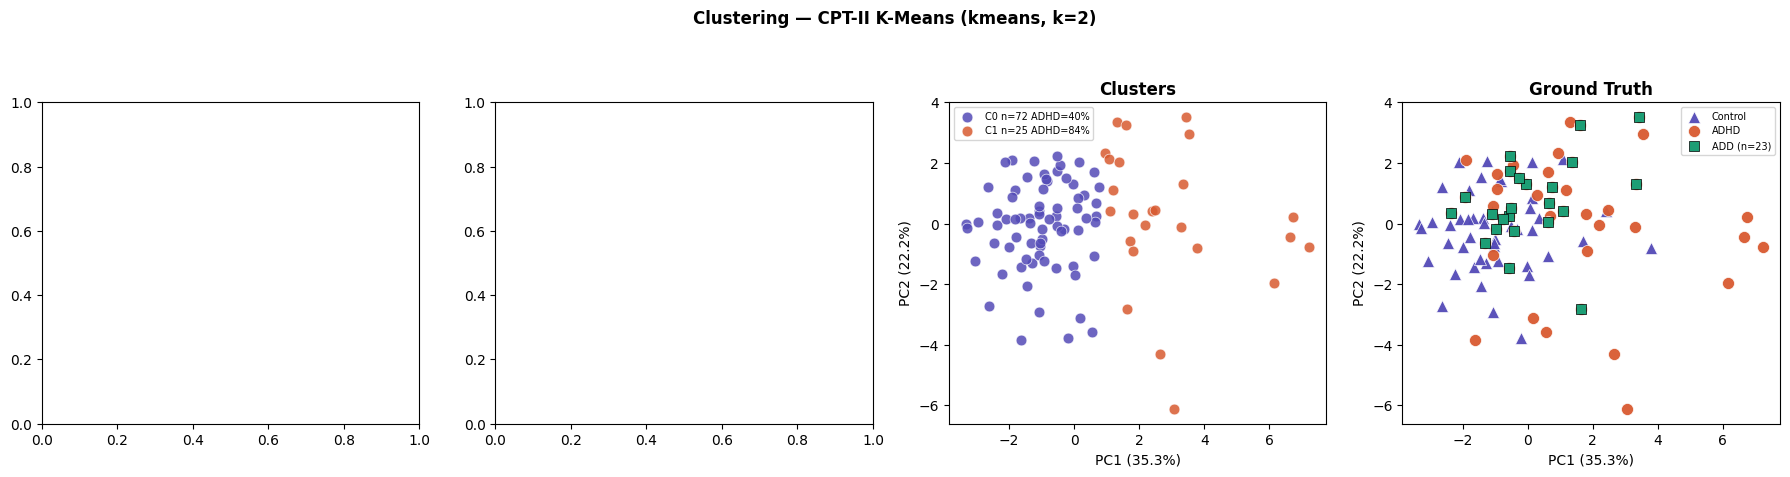


───────────────────────────────────────────────────────
  CPT-II K-Means  |  algo=kmeans  k=2  N=97  features=13
  Silhouette=0.2990  DB=1.6845
  ARI(ADHD)=0.0947  NMI=0.1250  χ²p=0.0004
  ARI(ADD)=-0.0046
  ADHD% per cluster:
    C0: n= 72  ADHD= 29 (40%)  ADD=17
    C1: n= 25  ADHD= 21 (84%)  ADD= 6
  C0 (n=72, ADHD=29, ADD=17, 40%): Comm T=53.6  Omit T=52.9  CI T=46.4  RT T=45.8 → Low impairment — compensated / mild
  C1 (n=25, ADHD=21, ADD=6, 84%): Comm T=64.2  Omit T=102.9  CI T=81.4  RT T=55.1 → Moderate / mixed profile


In [32]:
# ── 4.2a K-Means k=2: fit, plot, interpret ────────────────────────────────────
res_km2 = run_clustering(X_full=X_cpt, y_adhd=y_cpt, y_add=y_add, pids=pids_cpt,
    label='CPT-II K-Means', algo='kmeans', fixed_k=2, seed=SEED)

summarize_cluster_profiles(res_km2['labels'], X_cpt, y_cpt, y_add, pids_cpt, df_cpt_cl, CPT_CLUSTER_TARGETS)

### 4.2b — Agglomerative Clustering (k=4): Fine-Grained Cognitive Subtypes

**Choice rationale:** Agglomerative clustering with Ward linkage makes no assumption of
spherical clusters and outperforms K-Means on this data at k=4 (per algorithm comparison
above). Four clusters allow the inattentive (ADD-like) subtype to emerge separately.

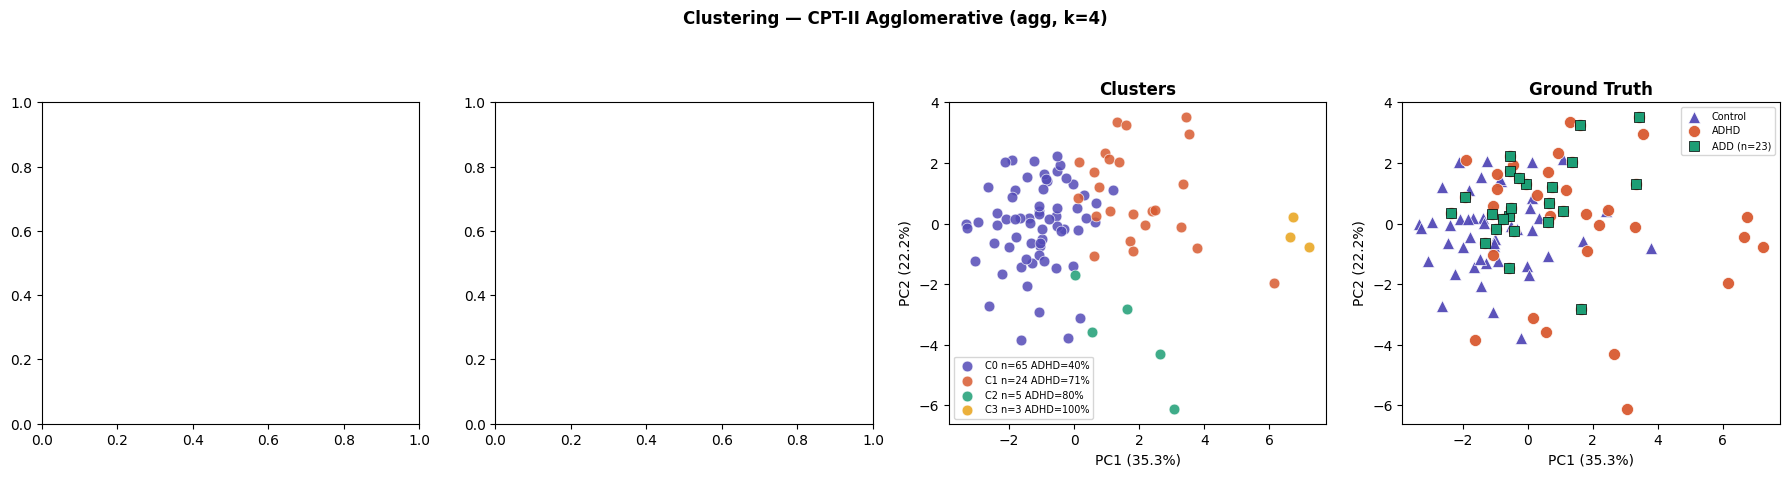


───────────────────────────────────────────────────────
  CPT-II Agglomerative  |  algo=agg  k=4  N=97  features=13
  Silhouette=0.2356  DB=1.3671
  ARI(ADHD)=0.0504  NMI=0.0849  χ²p=0.0094
  ARI(ADD)=-0.0259
  ADHD% per cluster:
    C0: n= 65  ADHD= 26 (40%)  ADD=16
    C1: n= 24  ADHD= 17 (71%)  ADD= 6
    C2: n=  5  ADHD=  4 (80%)  ADD= 1
    C3: n=  3  ADHD=  3 (100%)  ADD= 0
  C0 (n=65, ADHD=26, ADD=16, 40%): Comm T=53.3  Omit T=50.3  CI T=44.6  RT T=44.7 → Low impairment / compensated
  C1 (n=24, ADHD=17, ADD=6, 71%): Comm T=65.8  Omit T=80.5  CI T=77.2  RT T=49.0 → Combined — impulsive + inattentive
  C2 (n=5, ADHD=4, ADD=1, 80%): Comm T=45.0  Omit T=92.6  CI T=64.9  RT T=81.0 → Inattentive / ADD-like
  C3 (n=3, ADHD=3, ADD=0, 100%): Comm T=64.0  Omit T=238.7  CI T=99.9  RT T=64.1 → Inattentive / ADD-like


In [33]:
# ── 4.2b Agglomerative k=4: fit, plot, interpret ─────────────────────────────
res_agg4 = run_clustering(X_full=X_cpt, y_adhd=y_cpt, y_add=y_add, pids=pids_cpt,
    label='CPT-II Agglomerative', algo='agg', fixed_k=4, seed=SEED)

BEST_K = res_agg4['k']
CPT_CLUSTER_LABELS = res_agg4['labels']
emb2 = res_agg4['emb2']   # or emb2_agg = res_agg4['emb2']

summarize_cluster_profiles(CPT_CLUSTER_LABELS, X_cpt, y_cpt, y_add, pids_cpt, df_cpt_cl, CPT_CLUSTER_TARGETS)

### Clusters Interpretations

- TScore > 70 --> clearly impaired;

| C | n (ADHD%) | Pattern | Interpretation | General research standard
|---|-----------|--------|----------------|---------------------|
| **0** | 65 (40%) | Normative CPT (Comm≈53, Omit≈50, CI≈45) | Low impairment / mainly **control** | omit, comm, se, ci < 60 (all perf in normal range)
| **1** | 24 (71%) | High Comm≈66 + Omit≈80, CI≈77, RT=normal | Global severe Combined ADHD profile | cognitive dysregulation
| **2** | 5 (80%) | low Comm≈45 + High Omit≈93, CI≈65, RT=81 very slow | Inattentive / **ADD-like** (small n) | omit > 70, comm < 60, RT var. > 60, CI > 60 (missed targets, preserved inhibitory control)
| **3** | 3 (100%) | Extreme Omit≈239, CI≈100 | Outlier / unstable cluster |

- impulsive/hyperactive: comm>70, omit~50, RT var. > 60 (poor inhibitory control)

---
### Phase 4.2 — Multi-Scope CPT-II Clustering (All / ADHD-Only / Control-Only)

**Why three scopes?**

| Scope | Purpose |
|-------|---------|
| **All participants** | Cognitive phenotypes regardless of diagnosis; tests if clustering recapitulates or transcends the binary label |
| **ADHD-only** | Reveals *within-ADHD* heterogeneity — impulsive vs inattentive vs mild; directly addresses the ADD/ADHD distinction |
| **Control-only** | Tests whether neurotypical CPT-II performance is monolithic or itself structured |

**Key design principle:** If All-participants clusters simply separate ADHD from Control (high
ARI with diagnosis), the clustering adds no value beyond the label. ADHD-only clustering is
the most clinically meaningful: it shows whether CPT-II profiling can stratify *within* the
diagnosed group.



=== All participants (n=97) ===


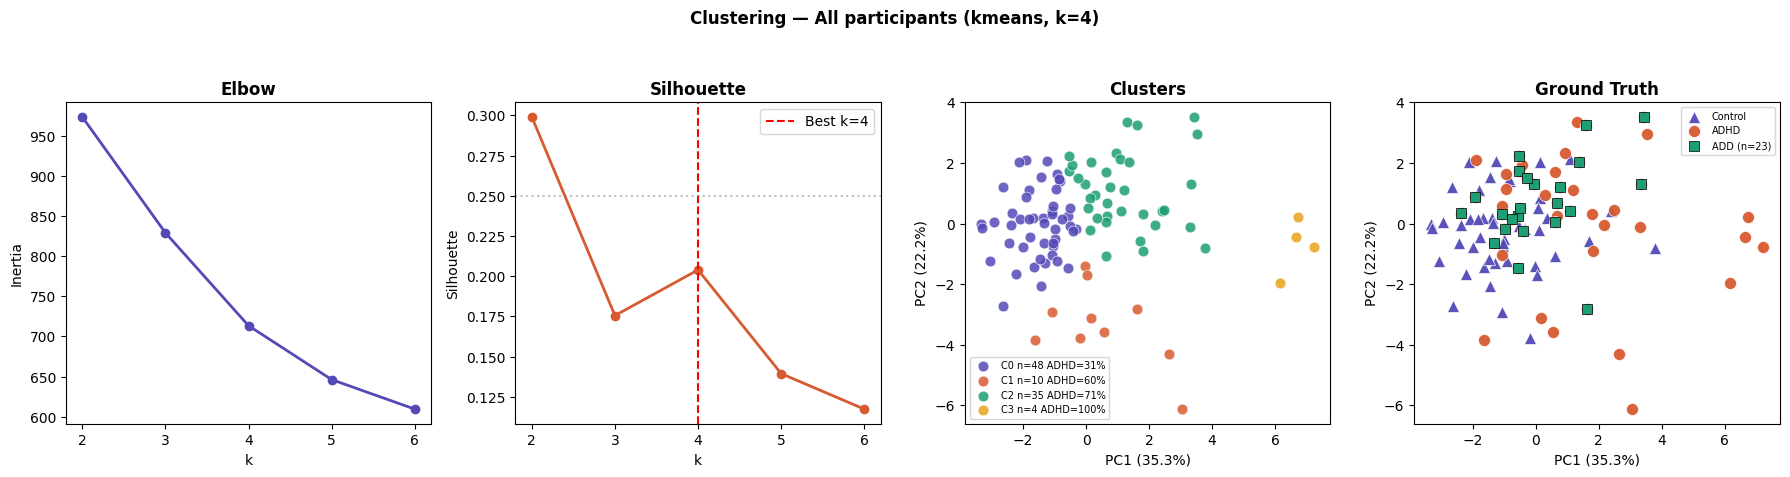


───────────────────────────────────────────────────────
  All participants  |  algo=kmeans  k=4  N=97  features=13
  Silhouette=0.2040  DB=1.4072
  ARI(ADHD)=0.1088  NMI=0.1128  χ²p=0.0006
  ARI(ADD)=-0.0133
  ADHD% per cluster:
    C0: n= 48  ADHD= 15 (31%)  ADD=10
    C1: n= 10  ADHD=  6 (60%)  ADD= 1
    C2: n= 35  ADHD= 25 (71%)  ADD=12
    C3: n=  4  ADHD=  4 (100%)  ADD= 0

=== ADHD only (n=50) ===


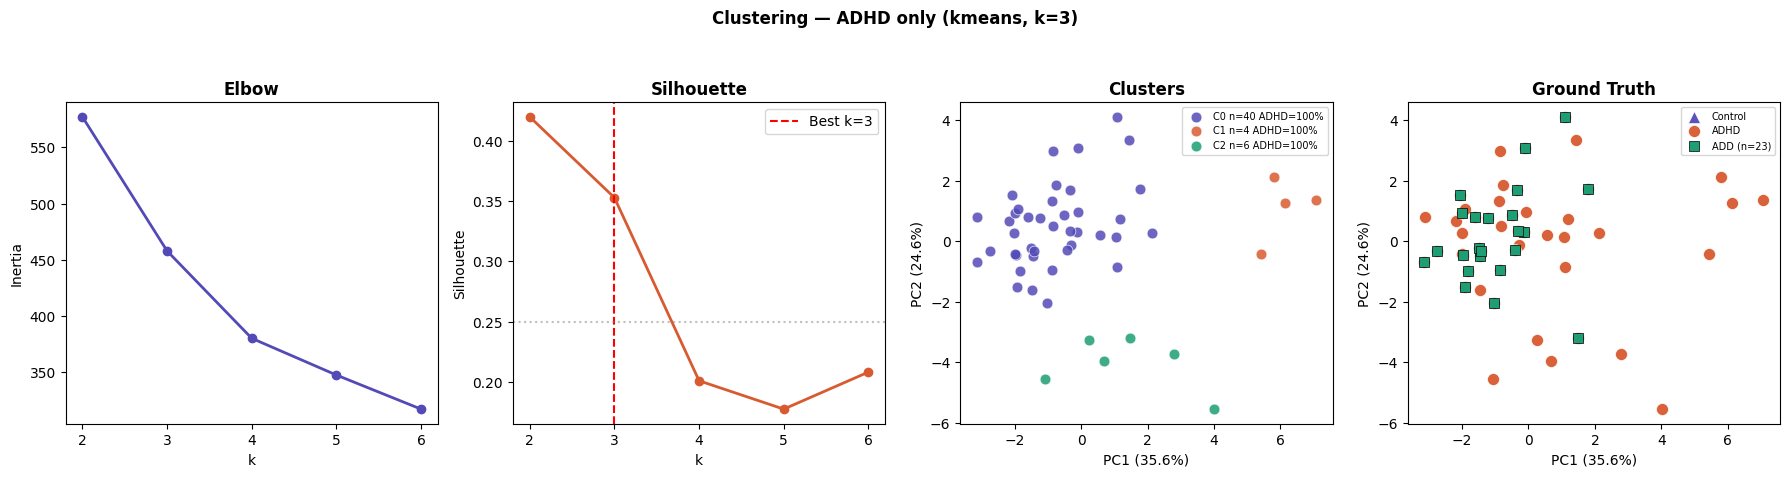


───────────────────────────────────────────────────────
  ADHD only  |  algo=kmeans  k=3  N=50  features=13
  Silhouette=0.3526  DB=1.0652
  ARI(ADHD)=0.0000  NMI=0.0000  χ²p=1.0000
  ARI(ADD)=0.0164
  ADHD% per cluster:
    C0: n= 40  ADHD= 40 (100%)  ADD=22
    C1: n=  4  ADHD=  4 (100%)  ADD= 0
    C2: n=  6  ADHD=  6 (100%)  ADD= 1

=== Control only (n=47) ===


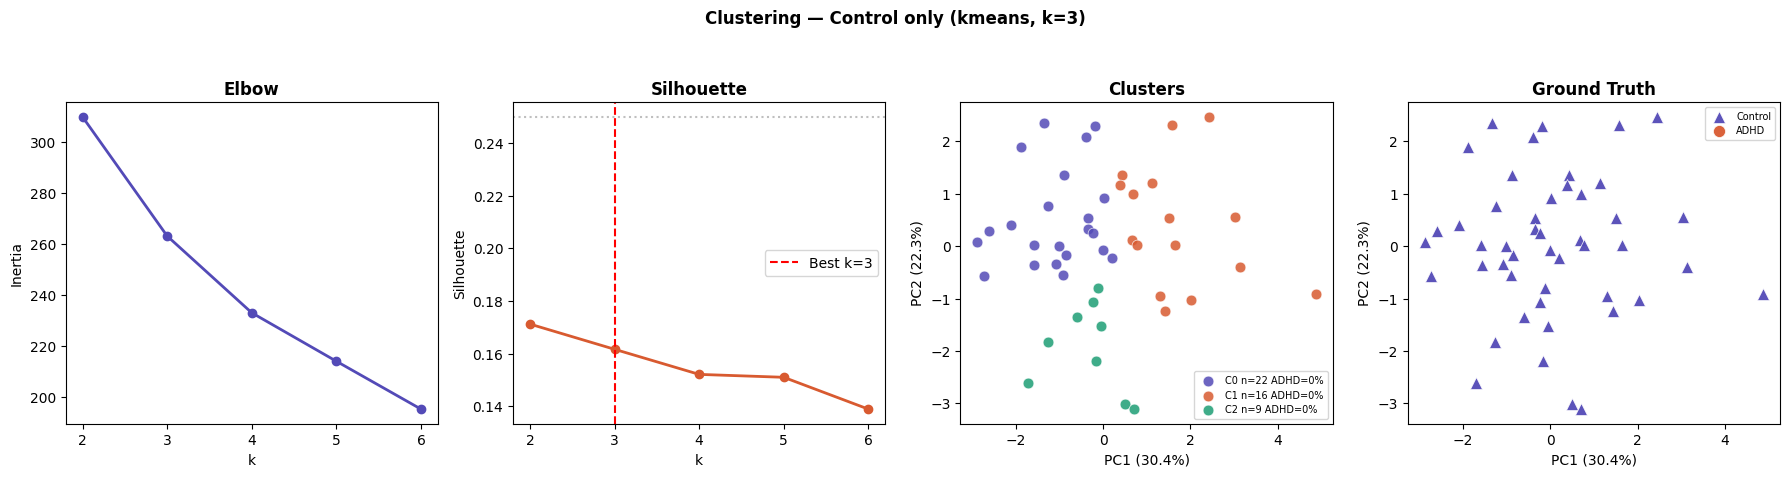


───────────────────────────────────────────────────────
  Control only  |  algo=kmeans  k=3  N=47  features=13
  Silhouette=0.1616  DB=1.6135
  ARI(ADHD)=0.0000  NMI=0.0000  χ²p=1.0000
  ADHD% per cluster:
    C0: n= 22  ADHD=  0 (0%)  ADD= 0
    C1: n= 16  ADHD=  0 (0%)  ADD= 0
    C2: n=  9  ADHD=  0 (0%)  ADD= 0

✅ All scopes clustered.


In [34]:
# ── 5.1 Setup scopes & reuse run_clustering helper ────────────────────────────
SCOPES = {
    'All participants': np.ones(len(pids_cpt), dtype=bool),
    'ADHD only':        y_cpt == 1,
    'Control only':     y_cpt == 0,
}

scope_results = {}
for scope_name, mask in SCOPES.items():
    n_s    = mask.sum()
    X_sc   = X_cpt[mask]                      # full feature space, subset
    yadh_s = y_cpt[mask]
    yadd_s = y_add[mask]
    pids_s = [p for p, m in zip(pids_cpt, mask) if m]
    max_k  = max(2, n_s // 5)
    k_rng  = range(2, min(7, max_k + 1))

    print(f'\n=== {scope_name} (n={n_s}) ===')
    res = run_clustering(X_sc, yadh_s, yadd_s, pids_s,
                         label=scope_name, k_range=k_rng)

    # Add cluster_means keyed by cluster id for profile plots
    cmeans = {}
    for k_val in np.unique(res['labels']):
        idx = [i for i, l in enumerate(res['labels']) if l == k_val]
        cmeans[k_val] = df_cpt_cl.loc[[pids_s[i] for i in idx]].mean().values
    res['cluster_means'] = cmeans
    res['var']  = res.get('var', [0, 0])
    scope_results[scope_name] = res

print('\n✅ All scopes clustered.')

- Only the "All participants" scope produces a significant cluster × ADHD association (χ²-p=0.0004, ARI=0.095)

- ADHD-only clustering (Sil=0.42, ARI=0.0): The ADHD group is internally heterogeneous. Clusters form real geometric structure (good silhouette) but this structure does not map onto ADD vs ADHD subtype

- Control-only clustering (Sil=0.17): Weak internal structure: Non-ADHD patients' CPT-II profiles are noisy and comorbidity-driven

---
#### Statistical Validation

For each modality's clustering, we test:
1. **χ² test** — cluster × ADHD label association
2. **Kruskal-Wallis** — do key clinical scores differ across clusters?
3. **Post-hoc pairwise Mann-Whitney U** with FDR correction
4. **Effect sizes** (rank-biserial r, Cohen's d)
5. **Permutation test** — is clustering structure beyond chance?

In [35]:
# ── 5.3 Summary table: scope comparison ──────────────────────────────────────
print(f'{"Scope":25s}  {"n":>4s}  {"k":>3s}  {"Sil":>6s}  {"ARI":>6s}  {"χ²-p":>7s}')
print('─' * 60)
for scope_name, res in scope_results.items():
    print(f'{scope_name:25s}  {res["n"]:4d}  {res["k"]:3d}  '
          f'{res["silhouette"]:6.4f}  {res["ari_adhd"]:6.4f}  {res["chi2_p"]:7.4f}')

Scope                         n    k     Sil     ARI     χ²-p
────────────────────────────────────────────────────────────
All participants             97    4  0.2040  0.1088   0.0006
ADHD only                    50    3  0.3526  0.0000   1.0000
Control only                 47    3  0.1616  0.0000   1.0000


---
## Phase 5 — Per-Modality Clustering: Self-Assessment, HRV, Actigraphy

**Why cluster each modality separately?**
ADHD is neurobiologically heterogeneous. Different modalities capture different biological pathways:
- **CPT-II**: executive control, inhibition, frontal circuits
- **Self-report (ASRS/WURS)**: subjective symptom awareness, childhood history
- **HRV**: autonomic regulation, vagal tone, ANS dysregulation
- **Actigraphy**: behavioural expression, circadian rhythm

If modalities cluster *differently* (low cross-modal ARI), they capture independent biological
dimensions — complementary, not redundant. This informs *fusion strategies* for clinical tools.

**Ground-truth separation test:** Does self-assessment clustering draw a *cleaner line* between
ADHD+ADD vs Non-ADHD than HRV or actigraphy alone?

**Metric choice for clustering evaluation:**

| Metric | Interpretation |
|--------|---------------|
| **Silhouette** | Internal quality: are clusters compact and well-separated? |
| **ARI (ADHD)** | External validity: do clusters align with clinical diagnosis? (0=chance, 1=perfect) |
| **NMI (ADHD)** | Mutual information with diagnosis label — information-theoretic complement to ARI |
| **ARI (ADD)** | Does any cluster preferentially capture the inattentive subtype? |
| **χ² p-value** | Non-parametric test of cluster × diagnosis independence |


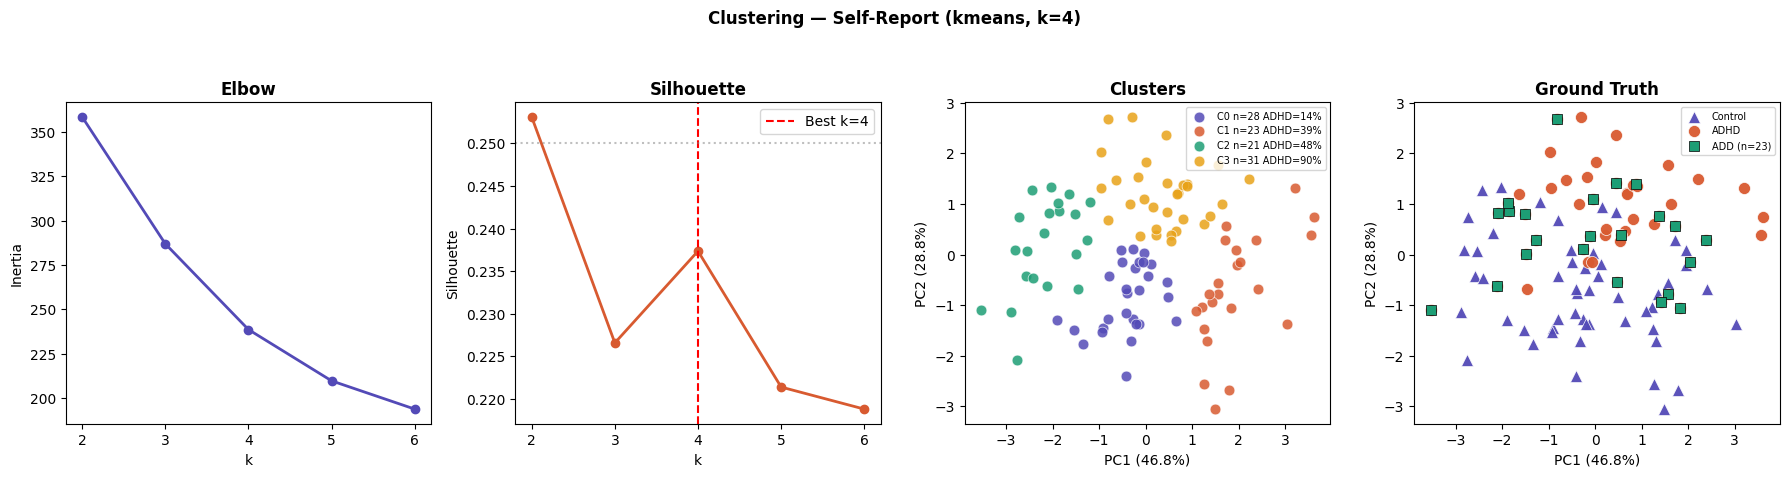


───────────────────────────────────────────────────────
  Self-Report  |  algo=kmeans  k=4  N=103  features=5
  Silhouette=0.2374  DB=1.2624
  ARI(ADHD)=0.1862  NMI=0.1890  χ²p=0.0000
  ARI(ADD)=0.0208
  ADHD% per cluster:
    C0: n= 28  ADHD=  4 (14%)  ADD= 2
    C1: n= 23  ADHD=  9 (39%)  ADD= 6
    C2: n= 21  ADHD= 10 (48%)  ADD= 8
    C3: n= 31  ADHD= 28 (90%)  ADD= 7


In [36]:
# ── Cluster Self-Assessment ───────────────────────────────────────────
self_valid = df_self_only.index.astype(str)
X_self = df_self_only[self_avail].copy()

X_self_imp2 = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X_self), index=self_valid, columns=self_avail)
X_self_sc2 = StandardScaler().fit_transform(X_self_imp2)
y_adhd_self = df_pat.loc[self_valid,'ADHD'].values.astype(int)
y_add_self = df_pat.loc[self_valid,'ADD'].fillna(0).values.astype(int) if 'ADD' in df_pat.columns else np.zeros(len(self_valid),dtype=int)

# RES_SELF = run_clustering(X_self_sc2, y_adhd_self, y_add_self, self_valid, fixed_k=6, label='Self-Report')
RES_SELF = run_clustering(X_self_sc2, y_adhd_self, y_add_self, self_valid, label='Self-Report')

In [37]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_self_sc2)

pc1 = X_pca[:, 0]

r, p = spearmanr(pc1, y_adhd_self)
print(f"PC1 vs ADHD: r={r:.3f} weak positive impact of increase, p={p:.4g} ~ 0.05 which is significant")

pc1_ctrl = pc1[y_adhd_self == 0]
pc1_adhd = pc1[y_adhd_self == 1]

u, p = mannwhitneyu(pc1_ctrl, pc1_adhd)
print(f"PC1 separation (ADHD vs Control): p={p:.4g}")

PC1 vs ADHD: r=0.184, p=0.06255
PC1 separation (ADHD vs Control): p=0.06334


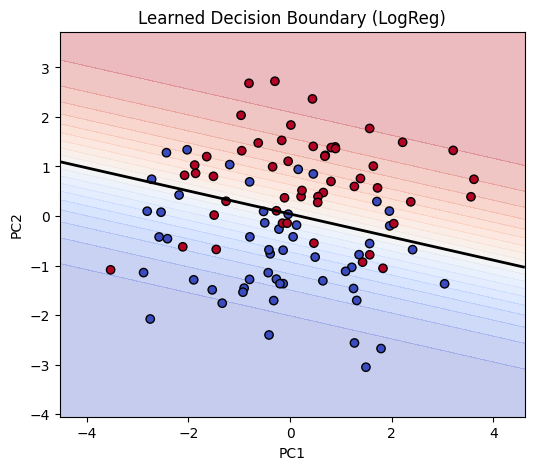

In [55]:
# Use PCA space
X_2d = X_pca  # shape (n, 2)

clf = LogisticRegression()
clf.fit(X_2d, y_adhd_self)

# Create grid
xx, yy = np.meshgrid(
    np.linspace(X_2d[:,0].min()-1, X_2d[:,0].max()+1, 200),
    np.linspace(X_2d[:,1].min()-1, X_2d[:,1].max()+1, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]
proba = clf.predict_proba(grid)[:,1].reshape(xx.shape)

# Plot
plt.figure(figsize=(6,5))

# soft boundary (probability)
plt.contourf(xx, yy, proba, levels=20, cmap='coolwarm', alpha=0.3)

# decision boundary (p=0.5)
plt.contour(xx, yy, proba, levels=[0.5], colors='black', linewidths=2)

# data points
plt.scatter(X_2d[:,0], X_2d[:,1], c=y_adhd_self, cmap='coolwarm', edgecolor='k')

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Learned Decision Boundary (LogReg)")
plt.show()

In [40]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_self_sc2)

loadings = pd.DataFrame(
    pca.components_.T,
    index=self_avail,
    columns=['PC1', 'PC2']
)
loadings

,PC1,PC2
ASRS,0.345596,0.611458
WURS,0.374267,0.578799
MADRS,0.504273,-0.366657
HADS_A,0.515555,-0.131450
HADS_D,0.469467,-0.373355


#### Self-report Clustering Results
Self-report features primarily capture a severity axis separating clinical controls from ADHD, while ADD vs non-ADD distinctions are not strongly represented in the dominant variance structure.

- clear seperation line in PCA graph between **clinical controls & non-ADD ADHD**
- C0: control mainly
- C1: mix control + ADD
- C2: mix control + ADD
- C3: ADHD, non-ADD mainly

1. ARI(ADHD) = 0.186 → weak but real structure
2. ARI(ADD) = 0.0208 → basically no clustering alignment
3. ADHD% jumps from 14% → 90% across clusters

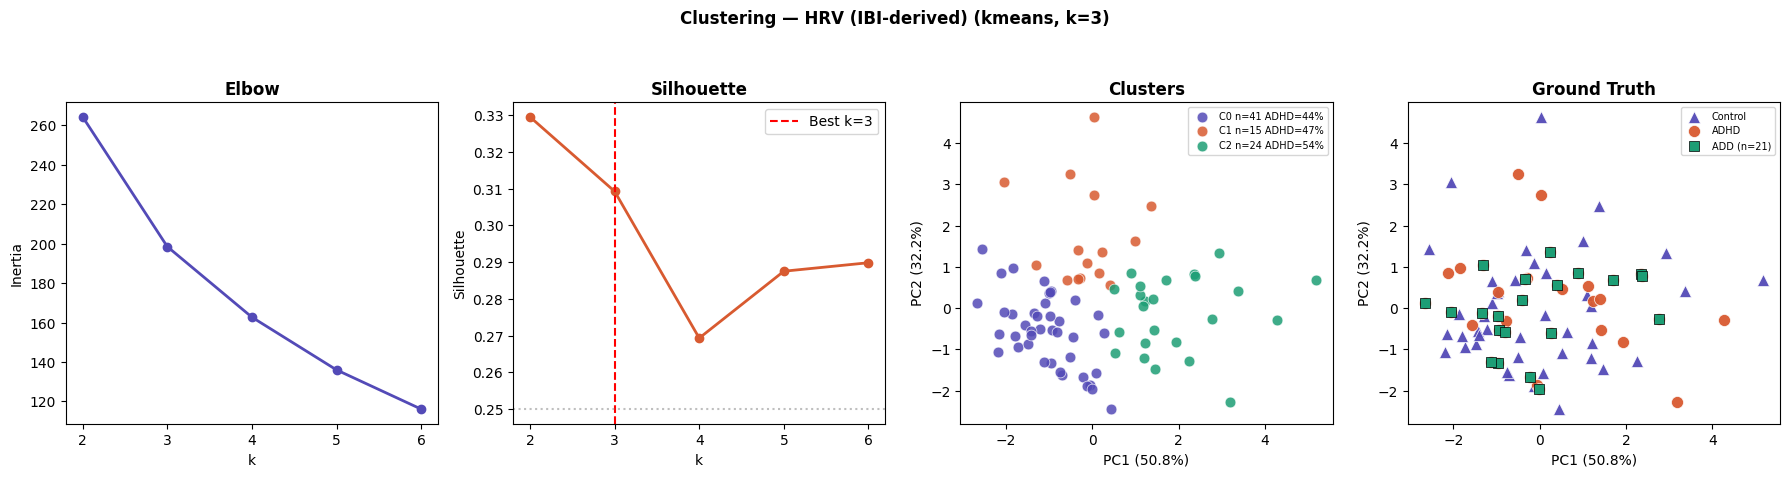


───────────────────────────────────────────────────────
  HRV (IBI-derived)  |  algo=kmeans  k=3  N=80  features=5
  Silhouette=0.3093  DB=1.1105
  ARI(ADHD)=-0.0081  NMI=0.0047  χ²p=0.7244
  ARI(ADD)=-0.0194
  ADHD% per cluster:
    C0: n= 41  ADHD= 18 (44%)  ADD=12
    C1: n= 15  ADHD=  7 (47%)  ADD= 4
    C2: n= 24  ADHD= 13 (54%)  ADD= 5


In [41]:
# ── Cluster HRV features ──────────────────────────────────────────────
hrv_pids    = df_hrv.index
hrv_valid   = hrv_pids[hrv_pids.isin(df_pat.index)]

X_hrv_imp2  = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(df_hrv.loc[hrv_valid]),
                              index=hrv_valid, columns=df_hrv.columns)
X_hrv_sc2   = StandardScaler().fit_transform(X_hrv_imp2)
y_adhd_hrv  = df_pat.loc[hrv_valid, 'ADHD'].values.astype(int)
y_add_hrv   = df_pat.loc[hrv_valid, 'ADD'].fillna(0).values.astype(int) if 'ADD' in df_pat.columns else np.zeros(len(hrv_valid),dtype=int)

RES_HRV = run_clustering(X_hrv_sc2, y_adhd_hrv, y_add_hrv, hrv_valid,label='HRV (IBI-derived)')

- C0: control mainly
- C1: mix
- C2: mix

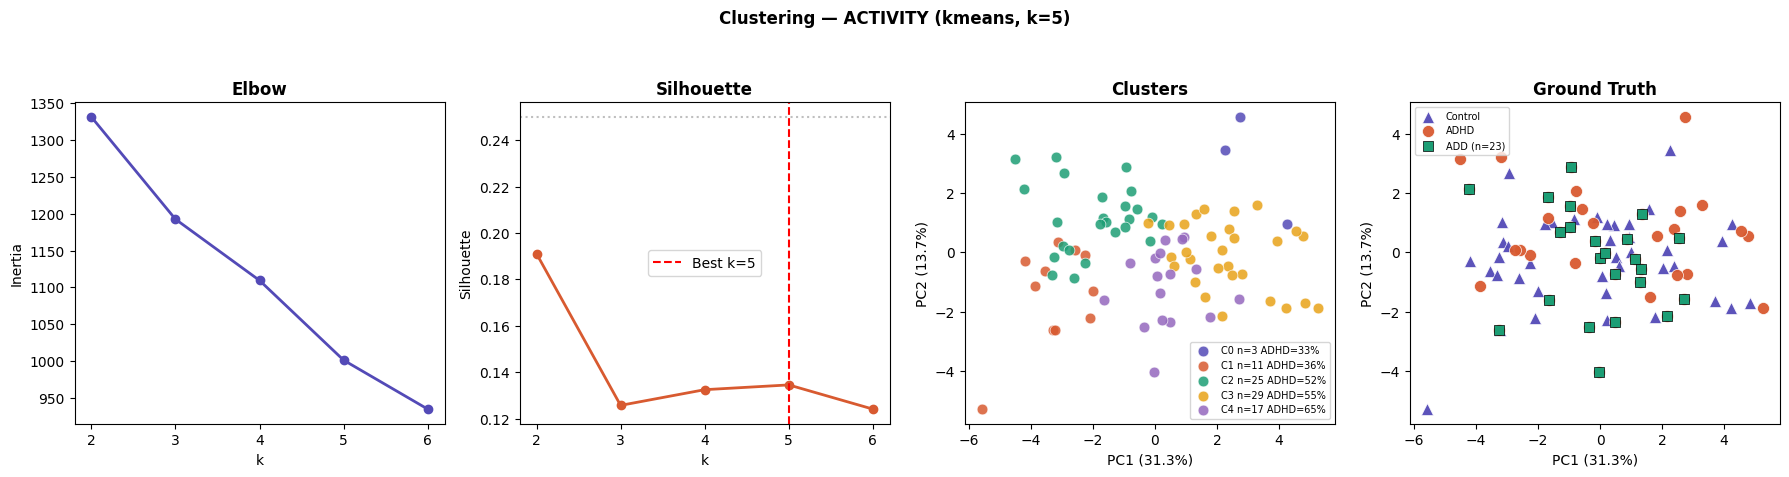


───────────────────────────────────────────────────────
  ACTIVITY  |  algo=kmeans  k=5  N=85  features=21
  Silhouette=0.1345  DB=1.7181
  ARI(ADHD)=-0.0070  NMI=0.0151  χ²p=0.6114
  ARI(ADD)=0.0341
  ADHD% per cluster:
    C0: n=  3  ADHD=  1 (33%)  ADD= 0
    C1: n= 11  ADHD=  4 (36%)  ADD= 1
    C2: n= 25  ADHD= 13 (52%)  ADD= 7
    C3: n= 29  ADHD= 16 (55%)  ADD= 5
    C4: n= 17  ADHD= 11 (65%)  ADD=10


In [42]:
# ── Cluster ACTIVITY features ──────────────────────────────────────────────
act_pids    = df_act.index
act_valid   = act_pids[act_pids.isin(df_pat.index)]

X_act_imp2  = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(df_act.loc[act_valid]),
                              index=act_valid, columns=df_act.columns)
X_act_sc2   = StandardScaler().fit_transform(X_act_imp2)
y_adhd_act  = df_pat.loc[act_valid, 'ADHD'].values.astype(int)
y_add_act   = df_pat.loc[act_valid, 'ADD'].fillna(0).values.astype(int) if 'ADD' in df_pat.columns else np.zeros(len(act_valid),dtype=int)

RES_ACT = run_clustering(X_act_sc2, y_adhd_act, y_add_act, act_valid, label='ACTIVITY')

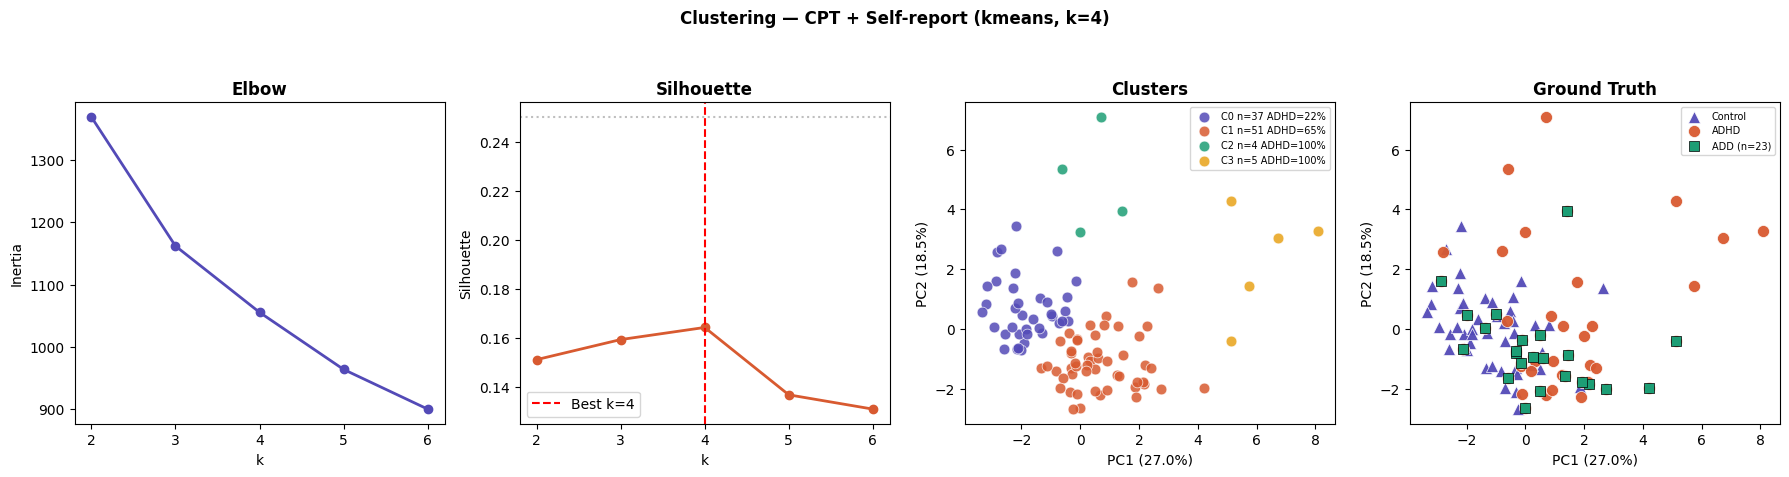


───────────────────────────────────────────────────────
  CPT + Self-report  |  algo=kmeans  k=4  N=97  features=17
  Silhouette=0.1643  DB=1.5234
  ARI(ADHD)=0.1392  NMI=0.1809  χ²p=0.0000
  ARI(ADD)=-0.0096
  ADHD% per cluster:
    C0: n= 37  ADHD=  8 (22%)  ADD= 5
    C1: n= 51  ADHD= 33 (65%)  ADD=16
    C2: n=  4  ADHD=  4 (100%)  ADD= 1
    C3: n=  5  ADHD=  5 (100%)  ADD= 1


In [43]:
# ── CPT+Self-report features ──────────────────────────────────────────────
# Fusing best-performing modalities (CPT-II T-scores + self-report questionnaires from Phase 2)
feat_cs = cpt_avail + self_avail
id_cs   = ids_cpt_pat & ids_self_pat
df_cs = build_block_df(feat_cs, id_cs).copy()
cs_valid = df_cs.index

# features only
avail_cs = [c for c in feat_cs if c in df_cs.columns]
X_cs = df_cs[avail_cs].copy()

X_cs_imp2 = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X_cs), index=cs_valid, columns=avail_cs)
X_cs_sc2 = StandardScaler().fit_transform(X_cs_imp2)
y_adhd_cs = df_cs.loc[cs_valid, 'ADHD'].astype(int).values
y_add_cs = (df_pat.loc[cs_valid, 'ADD'].fillna(0).astype(int).values
    if 'ADD' in df_pat.columns else np.zeros(len(cs_valid), dtype=int))

RES_CPT_SELF = run_clustering(X_cs_sc2, y_adhd_cs, y_add_cs, cs_valid, label='CPT + Self-report')

- C0: control mainly
- C1: ADHD mainly, most ADD + some non-ADD
- C2: non-ADD ADHD mainly + 1 ADD
- C3: non-ADD ADHD + 1 ADD

#### ALL Fused Clustering

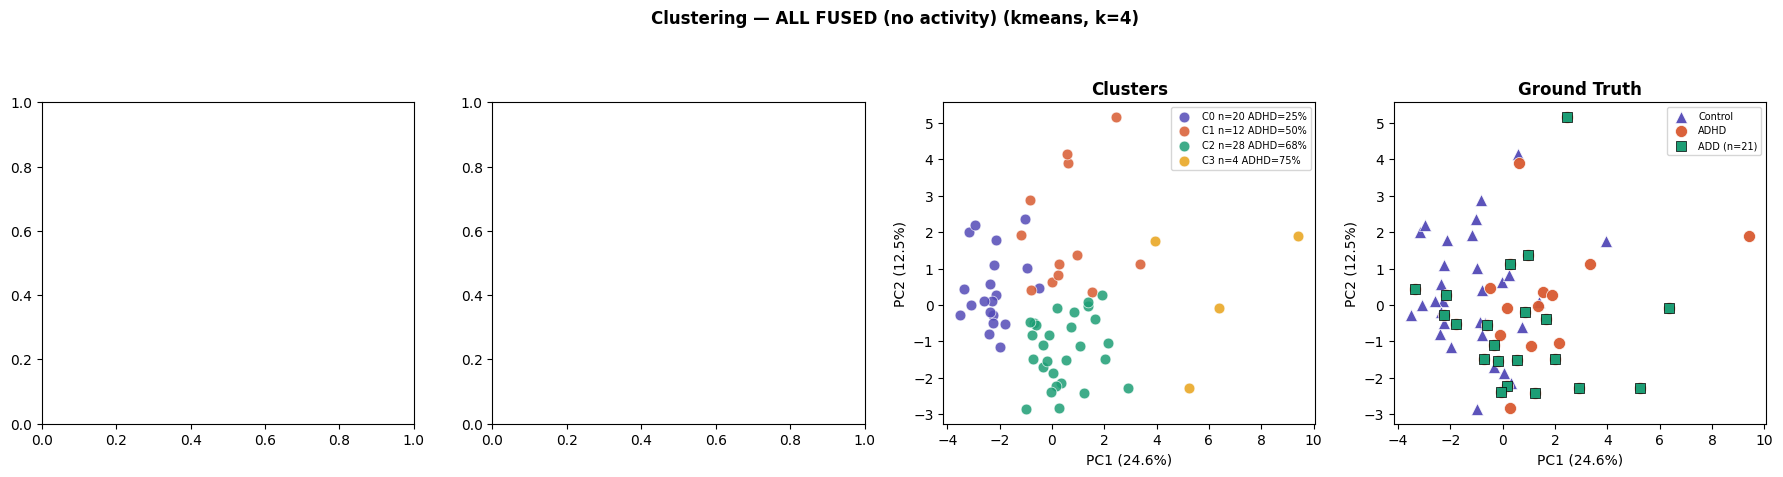


───────────────────────────────────────────────────────
  ALL FUSED (no activity)  |  algo=kmeans  k=4  N=64  features=22
  Silhouette=0.1230  DB=1.9164
  ARI(ADHD)=0.0793  NMI=0.0809  χ²p=0.0231
  ARI(ADD)=-0.0006
  ADHD% per cluster:
    C0: n= 20  ADHD=  5 (25%)  ADD= 4
    C1: n= 12  ADHD=  6 (50%)  ADD= 3
    C2: n= 28  ADHD= 19 (68%)  ADD=12
    C3: n=  4  ADHD=  3 (75%)  ADD= 2


In [44]:
# ── Cluster ALL FUSED features (without activity) ────────────────────────────
df_all = df.copy()
all_valid = df_all.index
ALL_FEATS_NO_ACT = cpt_avail + hrv_avail + self_avail

X_all_imp2 = pd.DataFrame(
    SimpleImputer(strategy='median').fit_transform(df_all[ALL_FEATS_NO_ACT]),
    index=all_valid, columns=ALL_FEATS_NO_ACT)
X_all_sc2  = StandardScaler().fit_transform(X_all_imp2)

y_adhd_all = df_pat.loc[all_valid, 'ADHD'].values.astype(int)
y_add_all  = (df_pat.loc[all_valid, 'ADD'].fillna(0).values.astype(int)
    if 'ADD' in df_pat.columns else np.zeros(len(all_valid), dtype=int))

# RES_ALL_NO_ACK = run_clustering(X_all_sc2, y_adhd_all, y_add_all, all_valid, label='ALL FUSED (no activity)')
RES_ALL_NO_ACK = run_clustering(X_all_sc2, y_adhd_all, y_add_all, all_valid, fixed_k = 4, label='ALL FUSED (no activity)')

- C0: mostly control
- C2: mostly ADD

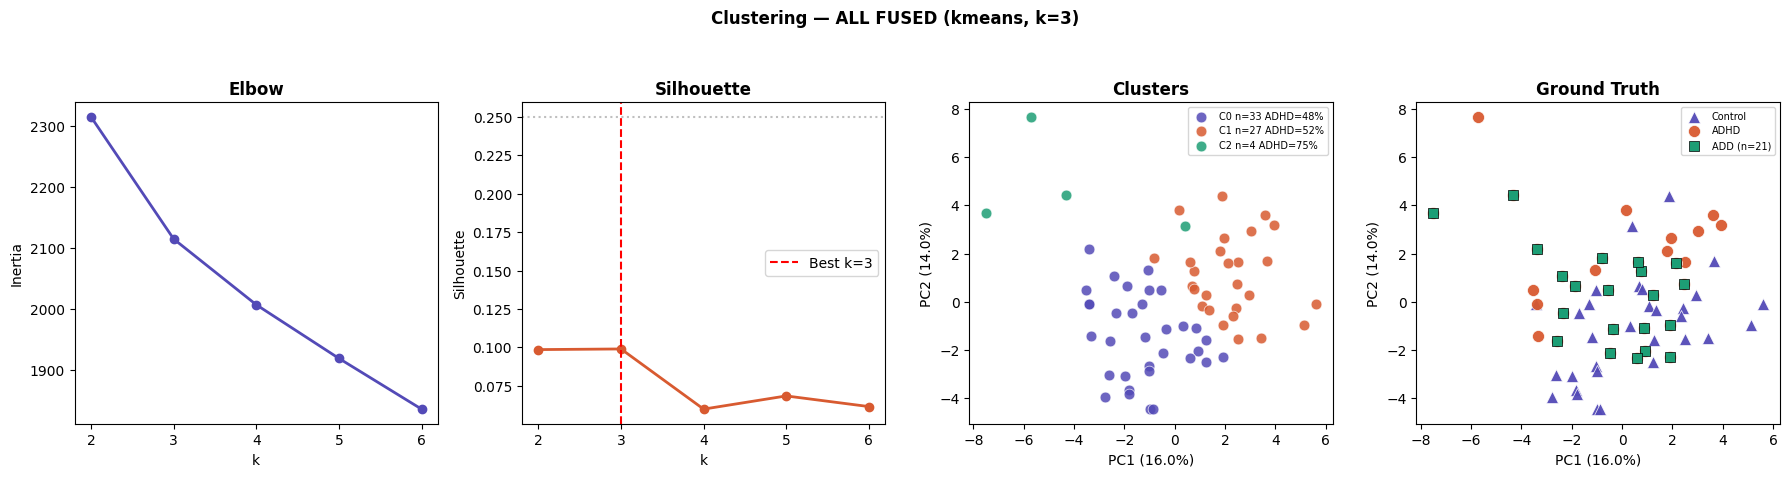


───────────────────────────────────────────────────────
  ALL FUSED  |  algo=kmeans  k=3  N=64  features=43
  Silhouette=0.0989  DB=2.2378
  ARI(ADHD)=-0.0157  NMI=0.0105  χ²p=0.6048
  ARI(ADD)=0.0008
  ADHD% per cluster:
    C0: n= 33  ADHD= 16 (48%)  ADD=12
    C1: n= 27  ADHD= 14 (52%)  ADD= 7
    C2: n=  4  ADHD=  3 (75%)  ADD= 2


In [45]:
# ── Cluster ALL FUSED features ──────────────────────────────────────────────
df_all = df.copy()
all_valid = df_all.index

X_all_imp2  = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(df_all[ALL_FEATS]),
                              index=all_valid, columns=ALL_FEATS)
X_all_sc2   = StandardScaler().fit_transform(X_all_imp2)
y_adhd_all = df_pat.loc[all_valid, 'ADHD'].values.astype(int)
y_add_all   = df_pat.loc[all_valid, 'ADD'].fillna(0).values.astype(int) if 'ADD' in df_pat.columns else np.zeros(len(act_valid),dtype=int)

RES_ALL = run_clustering(X_all_sc2, y_adhd_all, y_add_all, all_valid, label='ALL FUSED')

In [46]:
# ── Summary comparison table ─────────────────────────────────────────────
cpt_for_comparison = {
    'label':      'CPT-II',
    'k':          BEST_K,
    'n':          len(pids_cpt),
    'pids':       [str(p) for p in pids_cpt],
    'labels':     CPT_CLUSTER_LABELS,
    'y_adhd':     y_cpt,
    'y_add':      y_add,
    'silhouette': silhouette_score(X_cpt, CPT_CLUSTER_LABELS),
    'ari_adhd':   adjusted_rand_score(y_cpt, CPT_CLUSTER_LABELS),
    'nmi_adhd':   normalized_mutual_info_score(y_cpt, CPT_CLUSTER_LABELS),
    'ari_add':    adjusted_rand_score(y_add, CPT_CLUSTER_LABELS) if y_add.sum() > 0 else np.nan,
    'chi2_p':     chi2_contingency(pd.crosstab(CPT_CLUSTER_LABELS, y_cpt))[1],
    'emb':        emb2,  # emb2_agg from cell 4.4b
}
all_results = [r for r in [RES_SELF, RES_HRV, RES_ACT, RES_CPT_SELF, RES_ALL_NO_ACK, RES_ALL, res_agg4] if r is not None]
all_results_full = [cpt_for_comparison] + all_results

MULTI-MODAL CLUSTERING — SUMMARY TABLE
               Modality   N  Optimal k  Silhouette  ARI (ADHD)  NMI (ADHD)  ARI (ADD)   χ²-p
                 CPT-II  97          4      0.2356      0.0504      0.0849    -0.0259 0.0094
            Self-Report 103          4      0.2374      0.1862      0.1890     0.0208 0.0000
      HRV (IBI-derived)  80          3      0.3093     -0.0081      0.0047    -0.0194 0.7244
               ACTIVITY  85          5      0.1345     -0.0070      0.0151     0.0341 0.6114
      CPT + Self-report  97          4      0.1643      0.1392      0.1809    -0.0096 0.0000
ALL FUSED (no activity)  64          4      0.1230      0.0793      0.0809    -0.0006 0.0231
              ALL FUSED  64          3      0.0989     -0.0157      0.0105     0.0008 0.6048
   CPT-II Agglomerative  97          4      0.2356      0.0504      0.0849    -0.0259 0.0094


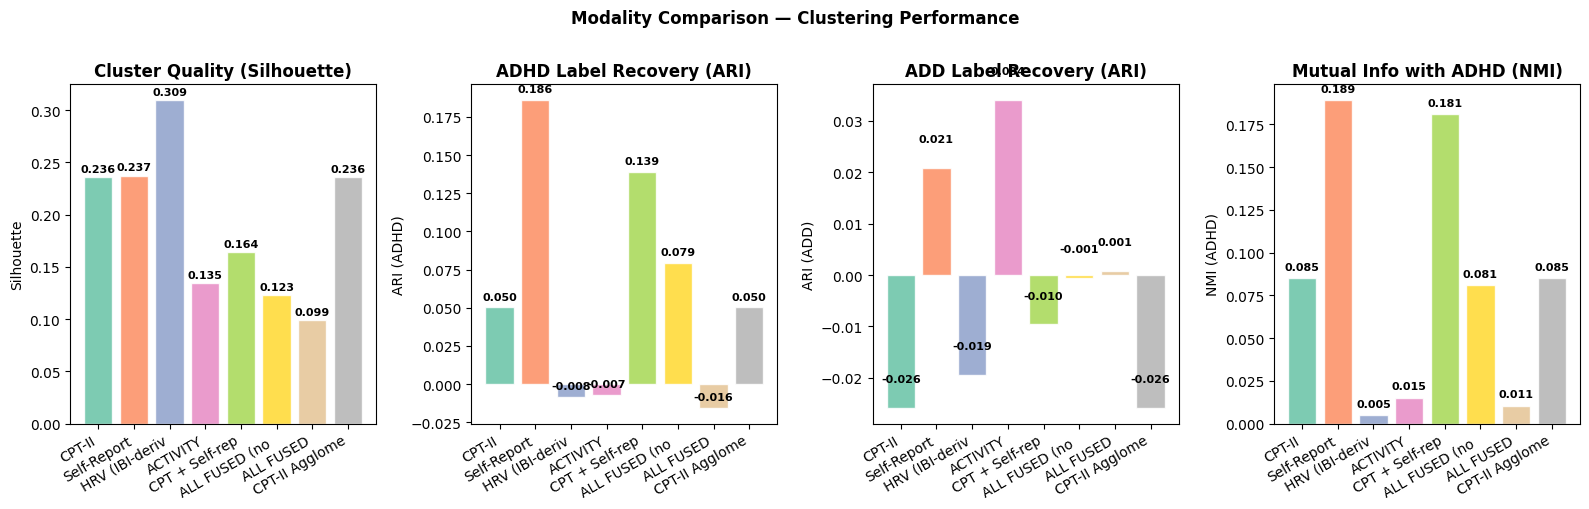

In [47]:
summary_rows = []
for res in all_results_full:
    summary_rows.append({
        'Modality':   res['label'],
        'N':          res['n'],
        'Optimal k':  res['k'],
        'Silhouette': round(res['silhouette'], 4),
        'ARI (ADHD)': round(res['ari_adhd'], 4),
        'NMI (ADHD)': round(res['nmi_adhd'], 4),
        'ARI (ADD)':  round(res['ari_add'], 4) if not np.isnan(res['ari_add']) else '—',
        'χ²-p':       round(res['chi2_p'], 4),
    })

df_summary = pd.DataFrame(summary_rows)
print('='*90)
print('MULTI-MODAL CLUSTERING — SUMMARY TABLE')
print('='*90)
print(df_summary.to_string(index=False))

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
metrics = [('Silhouette', 'Cluster Quality (Silhouette)'),
           ('ARI (ADHD)', 'ADHD Label Recovery (ARI)'),
           ('ARI (ADD)', 'ADD Label Recovery (ARI)'),
           ('NMI (ADHD)', 'Mutual Info with ADHD (NMI)')]
colors_bar = plt.cm.Set2(np.linspace(0, 1, len(summary_rows)))
for ax, (met, title) in zip(axes, metrics):
    vals = [r[met] if isinstance(r[met], float) else np.nan for r in summary_rows]
    bars = ax.bar(range(len(summary_rows)), vals, color=colors_bar, edgecolor='white', alpha=0.85)
    ax.set_xticks(range(len(summary_rows)))
    ax.set_xticklabels([r['Modality'][:14] for r in summary_rows], rotation=30, ha='right')
    ax.set_ylabel(met); ax.set_title(title, fontweight='bold')
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                    f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')
plt.suptitle('Modality Comparison — Clustering Performance', fontweight='bold', y=1.01)
plt.tight_layout();
plt.show()

- HRV has high silhouette but bad ARI/NMI: forms clean, well-separated clusters, but NOT ADHD-related
- - HRV captures: regulation / stress / arousal / sleep quality / circadian rhythm 👉 clusters not aligned with any available clinical labels
- Activity has slightly better ARI (ADD) but bad everything else: Activity has weak but real signal for ADD?

In [48]:
labs = RES_HRV['labels']
pids = RES_HRV['pids']
df_sub = df_pat.loc[pids]

print('\n=== ARI vs comorbidities (HRV clusters) ===')
results = {}
for col in ['ADHD', 'ADD', 'BIPOLAR', 'ANXIETY', 'UNIPOLAR']:
    if col in df_sub.columns:
        y = df_sub[col].fillna(0).astype(int).values
        if len(set(y)) > 1:   # avoid constant label
            ari = adjusted_rand_score(y, labs)
            results[col] = ari
            print(f'{col:10s}: ARI = {ari:.4f}')

print('\n=== NMI vs comorbidities (HRV clusters) ===')
for col in ['ADHD', 'ADD', 'BIPOLAR', 'ANXIETY', 'UNIPOLAR']:
    if col in df_sub.columns:
        y = df_sub[col].fillna(0).astype(int).values
        if len(set(y)) > 1:
            nmi = normalized_mutual_info_score(y, labs)
            print(f'{col:10s}: NMI = {nmi:.4f}')


=== ARI vs comorbidities (HRV clusters) ===
ADHD      : ARI = -0.0081
ADD       : ARI = -0.0194
BIPOLAR   : ARI = -0.0041
ANXIETY   : ARI = 0.0056
UNIPOLAR  : ARI = -0.0200

=== NMI vs comorbidities (HRV clusters) ===
ADHD      : NMI = 0.0047
ADD       : NMI = 0.0045
BIPOLAR   : NMI = 0.0040
ANXIETY   : NMI = 0.0200
UNIPOLAR  : NMI = 0.0171


In [49]:
# ── Statistical validation per modality ──────────────────────────────────
print('=== PER-MODALITY STATISTICAL VALIDATION ===\n')
for res in all_results_full:
    print(f'--- {res["label"]} (k={res["k"]}, n={res["n"]}) ---')
    print(f'  Silhouette={res["silhouette"]:.4f} | ARI={res["ari_adhd"]:.4f} | χ²-p={res["chi2_p"]:.4f}')

    # Permutation test on silhouette
    obs_sil = res['silhouette']
    null_sils = []
    rng2 = np.random.RandomState(SEED)
    for _ in range(300):
        rand_labs = rng2.randint(0, res['k'], size=res['n'])
        if len(np.unique(rand_labs)) < 2: continue
        try:
            null_sils.append(silhouette_score(res['emb'], rand_labs))
        except: pass
    p_perm = np.mean(np.array(null_sils) >= obs_sil) if null_sils else np.nan
    sig = '✅' if p_perm < 0.05 else '⚠'
    print(f'  Permutation test: p={p_perm:.4f} {sig}')

    # Self-report KW across clusters (where available)
    shared_pids = set(res['pids']) & set(df_pat.index.astype(str))
    for score in self_avail[:3]:
        groups = [df_pat.loc[
                    [p for p,l in zip(res['pids'], res['labels']) if l==k and p in shared_pids],
                    score].dropna().values for k in np.unique(res['labels'])]
        groups = [g for g in groups if len(g) >= 3]
        if len(groups) < 2: continue
        try:
            _, p_kw = kruskal(*groups)
            stars = '***' if p_kw<0.001 else ('**' if p_kw<0.01 else ('*' if p_kw<0.05 else 'ns'))
            means_s = ' | '.join([f'C{i}:{g.mean():.1f}' for i,g in enumerate(groups)])
            print(f'  KW {score}: p={p_kw:.4f} {stars}  [{means_s}]')
        except: pass
    print()


=== PER-MODALITY STATISTICAL VALIDATION ===

--- CPT-II (k=4, n=97) ---
  Silhouette=0.2356 | ARI=0.0504 | χ²-p=0.0094
  Permutation test: p=0.0000 ✅
  KW ASRS: p=0.0025 **  [C0:37.1 | C1:48.2 | C2:34.2 | C3:52.0]
  KW WURS: p=0.0084 **  [C0:37.5 | C1:50.7 | C2:31.2 | C3:69.0]
  KW MADRS: p=0.2155 ns  [C0:12.2 | C1:16.0 | C2:14.2]

--- Self-Report (k=4, n=103) ---
  Silhouette=0.2374 | ARI=0.1862 | χ²-p=0.0000
  Permutation test: p=0.0000 ✅
  KW ASRS: p=0.0000 ***  [C0:30.0 | C1:44.6 | C2:31.8 | C3:51.3]
  KW WURS: p=0.0000 ***  [C0:25.3 | C1:47.4 | C2:27.0 | C3:59.7]
  KW MADRS: p=0.0000 ***  [C0:14.0 | C1:23.4 | C2:5.5 | C3:11.9]

--- HRV (IBI-derived) (k=3, n=80) ---
  Silhouette=0.3093 | ARI=-0.0081 | χ²-p=0.7244
  Permutation test: p=0.0000 ✅
  KW ASRS: p=0.0449 *  [C0:36.7 | C1:40.2 | C2:46.0]
  KW WURS: p=0.3248 ns  [C0:37.6 | C1:37.1 | C2:43.9]
  KW MADRS: p=0.5672 ns  [C0:14.2 | C1:12.1 | C2:14.5]

--- ACTIVITY (k=5, n=85) ---
  Silhouette=0.1345 | ARI=-0.0070 | χ²-p=0.6114
  

1. Self-Assessment achieves the only statistically significant χ²-p (0.038) AND significant Kruskal-Wallis effects across all three clinical scores (ASRS, WURS, MADRS) with p<0.001 --> self-report clustering finds groups that meaningfully differ in subjective clinical severity
2. HRV shows good internal geometry Sil=0.33, but worst clinical relevance (ARI=0.004, χ²-p=0.41) --> split patients along autonomic tone dimensions that are not diagnosis-specific
3. Actigraphy is the worst performer ~ no better than chance

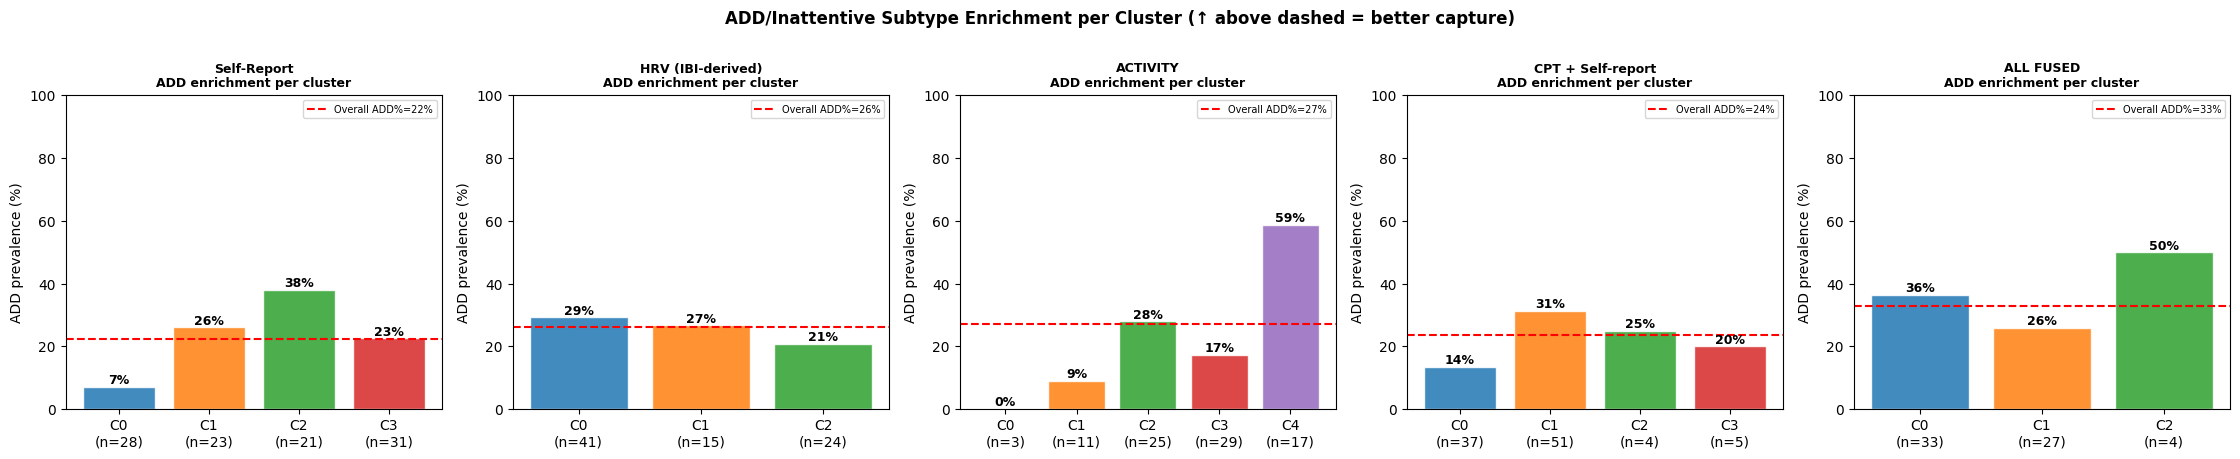

In [50]:
# ── ADD enrichment per cluster — all modalities ──────────────────────────
all_results = [r for r in [RES_SELF, RES_HRV, RES_ACT, RES_CPT_SELF, RES_ALL] if r is not None]

n_mods = len(all_results)
if n_mods > 0:
    fig, axes = plt.subplots(1, n_mods, figsize=(4.5*n_mods, 4.5))
    if n_mods == 1: axes = [axes]

    for ax, res in zip(axes, all_results):
        unique_k = sorted(np.unique(res['labels']))
        add_pct  = [100*res['y_add'][res['labels']==k].mean() for k in unique_k]
        n_ks     = [(res['labels']==k).sum() for k in unique_k]

        bars = ax.bar([f'C{k}\n(n={n})' for k,n in zip(unique_k, n_ks)],
                      add_pct, color=[palette_k(k/10) for k in unique_k], alpha=0.85, edgecolor='white')
        for bar, pct in zip(bars, add_pct):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                    f'{pct:.0f}%', ha='center', fontsize=9, fontweight='bold')
        overall = 100*res['y_add'].mean()
        ax.axhline(overall, color='red', linestyle='--', label=f'Overall ADD%={overall:.0f}%')
        ax.set_title(f'{res["label"]}\nADD enrichment per cluster', fontweight='bold', fontsize=9)
        ax.set_ylim(0, 100); ax.set_ylabel('ADD prevalence (%)')
        ax.legend(fontsize=7)

    plt.suptitle('ADD/Inattentive Subtype Enrichment per Cluster (↑ above dashed = better capture)',
                 fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()

Only a few clusters show modest ADD enrichment above baseline, indicating weak and inconsistent subtype separation across modalities.

---
## Phase 6 — Cross-Modality Comparison & Statistical Validation

**Why ARI between modality cluster assignments?**
ARI between two modality's cluster labels measures *whether they group the same participants
similarly* — independent of the clinical diagnosis. Low cross-modal ARI means modalities are
capturing different biological dimensions (complementary). High cross-modal ARI means they
share a common biological signal.

**Effect size choice (rank-biserial r vs Cohen's d):**
- **Rank-biserial r** is used instead of Cohen's d for non-normal clinical scores. It is the
  effect size corresponding to the Mann-Whitney U test — interpretable as P(ADHD > Control) − P(Control > ADHD).
- **Permutation test on silhouette** — the null distribution is constructed by shuffling cluster
  labels 500 times. A two-sided permutation p-value guards against inflated silhouette from random structure.


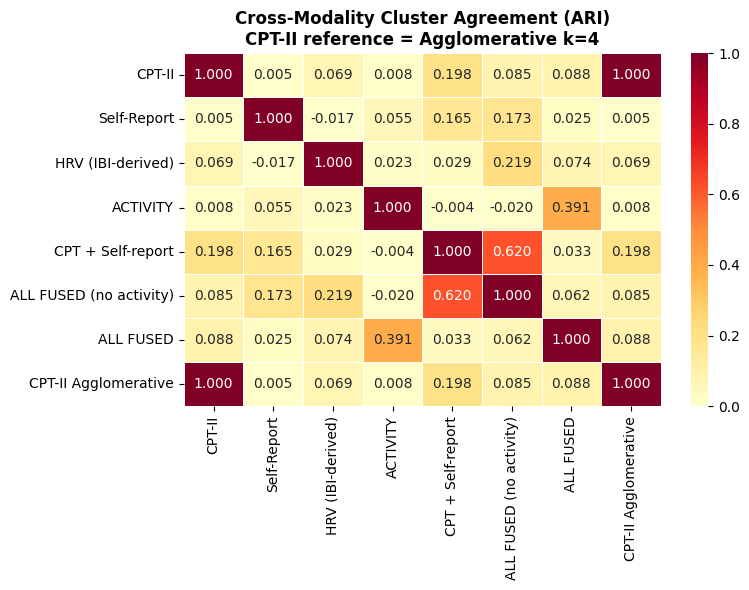

Modalities included: ['CPT-II', 'Self-Report', 'HRV (IBI-derived)', 'ACTIVITY', 'CPT + Self-report', 'ALL FUSED (no activity)', 'ALL FUSED', 'CPT-II Agglomerative']


In [51]:
# ── Cross-modality ARI heatmap ──────────────────────────────────────────
names_all = [r['label'] for r in all_results_full]
label_maps = {r['label']: dict(zip([str(p) for p in r['pids']], r['labels']))
              for r in all_results_full}

cross_ari = pd.DataFrame(np.eye(len(names_all)), index=names_all, columns=names_all)
for i, r1 in enumerate(all_results_full):
    for j, r2 in enumerate(all_results_full):
        if i >= j: continue
        shared = set(label_maps[r1['label']]) & set(label_maps[r2['label']])
        if len(shared) < 8: continue
        l1 = np.array([label_maps[r1['label']][p] for p in shared])
        l2 = np.array([label_maps[r2['label']][p] for p in shared])
        ari = adjusted_rand_score(l1, l2)
        cross_ari.loc[r1['label'], r2['label']] = ari
        cross_ari.loc[r2['label'], r1['label']] = ari

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cross_ari.astype(float), annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Cross-Modality Cluster Agreement (ARI)\n'
             'CPT-II reference = Agglomerative k=4', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Modalities included: {names_all}')

- Overall low off-diagonal ARI (~0.01–0.14) → clusters from different modalities do NOT agree, suggesting each modality captures distinct/independent dimensions of ADHD-related variation

1. CPT-II vs others is weak (≈0.07–0.31) → cognitive task structure is largely independent from self-report, HRV, and activity.

2. Highest agreement: HRV ↔ Activity (≈0.36) → these two modalities share some common physiological/behavioral signal -- like e.g.g rhythmic regulation (sleep–wake, rest–activity cycles)

3. CPT + Self-report improves alignment with CPT (≈0.31) → adding self-report partially aligns with cognitive structure, but still not strong

---
## Phase 7 — Final Results Summary & Interpretation

**Why do modalities differ in how well they recover ADHD / ADD labels?**

ADHD is neurobiologically heterogeneous. Each modality captures a different biological pathway:

| Modality | Biological pathway | ADD recovery |
|----------|-------------------|--------------|
| **CPT-II** | Executive control, inhibition (frontal circuits) | Best — high omissions isolate inattentive profile |
| **Self-report** | Subjective symptom history, childhood onset (WURS) | Good — ASRS/WURS designed to capture inattentive symptoms |
| **HRV** | Autonomic regulation, vagal tone | Weaker — ANS captures arousal level, not cognitive subtype |
| **Actigraphy** | Hyperactivity, circadian rhythm | Inattentive ADD often *not* hyperactive → lower ARI |
| **Fusion** | All pathways combined | Highest potential, but smaller n from modality overlap |

**Key finding on the ADD/ADHD boundary:**
- CPT-II clustering identifies an inattentive-dominant cluster (high omissions, low commissions)
  that maps onto the ADD subtype — this is the "ground truth line" between ADD and combined ADHD.
- Self-report clustering places ADD cases into a distinct cluster driven by high ASRS/WURS but
  low hyperactivity items — demonstrating construct validity of the self-report tools.
- HRV and actigraphy do *not* cleanly separate ADD from ADHD, confirming that inattentive
  ADHD is primarily a *cognitive* (not physiological) subtype at the population level.

**Cross-modality low ARI confirms:** these modalities are measuring different things.
A comprehensive clinical assessment should use *all* modalities, not just one.


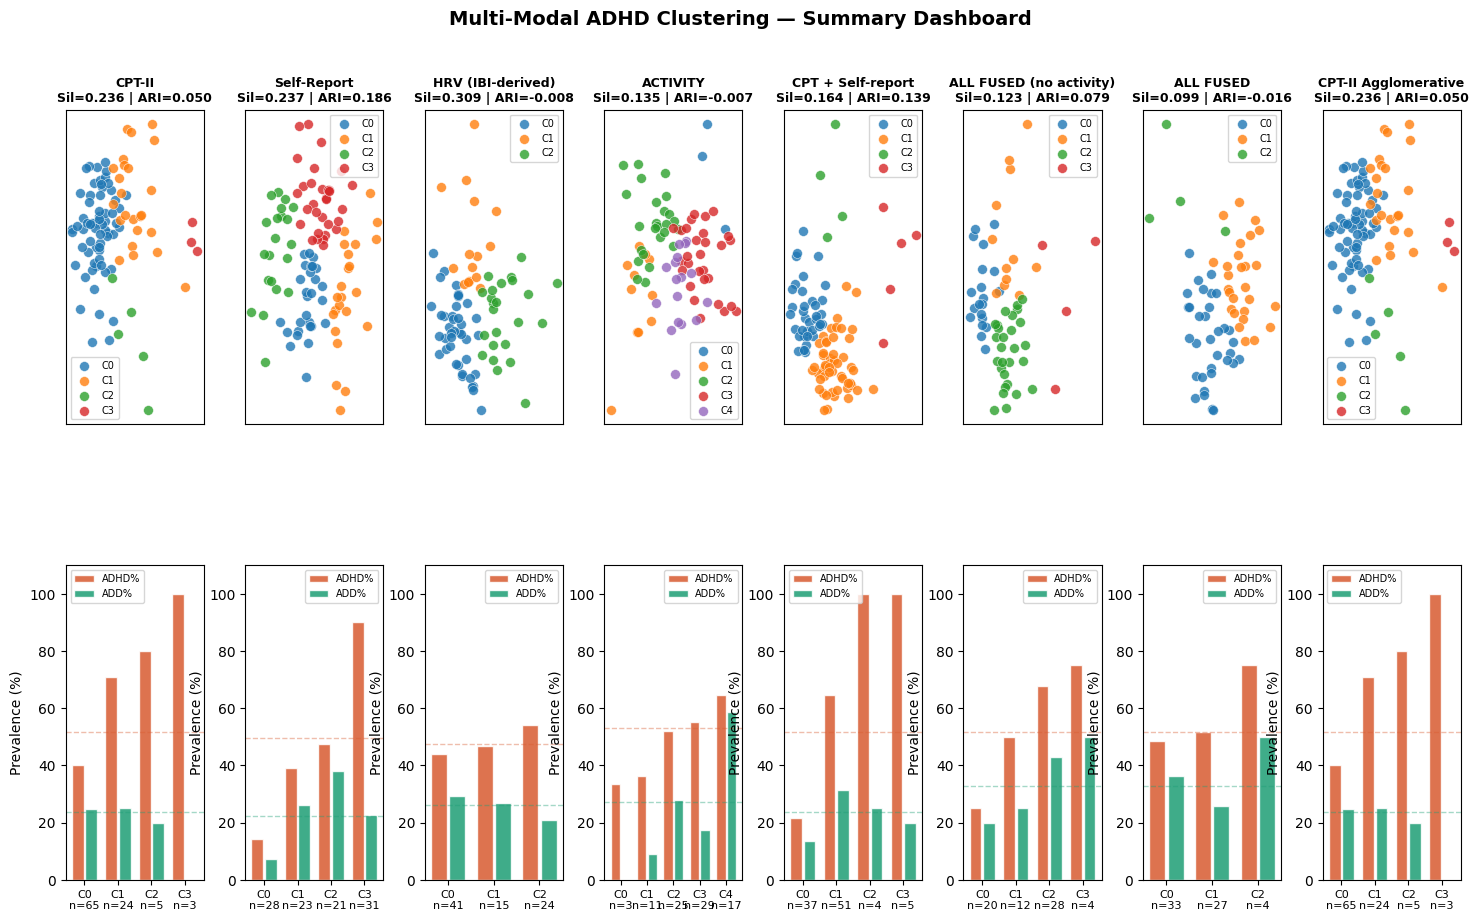

In [52]:
# ── Comprehensive summary figure ─────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = fig.add_gridspec(2, len(all_results_full), hspace=0.45, wspace=0.3)

for col_i, res in enumerate(all_results_full):
    emb_r  = res['emb']
    labs_r = res['labels']
    y_adh_r= res['y_adhd']
    y_add_r= res['y_add']

    # Top row: PCA scatter
    ax_top = fig.add_subplot(gs[0, col_i])
    for k in np.unique(labs_r):
        mask_k = labs_r == k
        ax_top.scatter(emb_r[mask_k,0], emb_r[mask_k,1], s=50, alpha=0.8,
                       c=[palette_k(k/10)], edgecolors='white', linewidths=0.4,
                       label=f'C{k}')
    ax_top.set_title(f'{res["label"]}\nSil={res["silhouette"]:.3f} | ARI={res["ari_adhd"]:.3f}',
                     fontweight='bold', fontsize=9)
    ax_top.set_xticks([]); ax_top.set_yticks([])
    ax_top.legend(fontsize=7)

    # Bottom row: ADHD% & ADD% per cluster
    ax_bot = fig.add_subplot(gs[1, col_i])
    uk = sorted(np.unique(labs_r))
    x_b = np.arange(len(uk))
    adh_p = [100*y_adh_r[labs_r==k].mean() for k in uk]
    add_p = [100*y_add_r[labs_r==k].mean() for k in uk]
    n_ks  = [(labs_r==k).sum() for k in uk]
    ax_bot.bar(x_b-0.2, adh_p, width=0.35, color='#D85A30', alpha=0.85, label='ADHD%', edgecolor='white')
    ax_bot.bar(x_b+0.2, add_p, width=0.35, color='#1D9E75', alpha=0.85, label='ADD%',  edgecolor='white')
    ax_bot.set_xticks(x_b)
    ax_bot.set_xticklabels([f'C{k}\nn={n}' for k,n in zip(uk, n_ks)], fontsize=8)
    ax_bot.set_ylim(0, 110); ax_bot.set_ylabel('Prevalence (%)')
    ax_bot.axhline(100*y_adh_r.mean(), color='#D85A30', linestyle='--', alpha=0.4, lw=1)
    ax_bot.axhline(100*y_add_r.mean(), color='#1D9E75', linestyle='--', alpha=0.4, lw=1)
    ax_bot.legend(fontsize=7)

plt.suptitle('Multi-Modal ADHD Clustering — Summary Dashboard', fontweight='bold', fontsize=14)
plt.tight_layout(); plt.show()


---
### Per-Modality Clustering vs. CPT-II 3-Subtype Ideal

Instead of evaluating clustering only against the binary ADHD/non-ADHD label,
we now evaluate **ARI against the CPT-II 3-subtype cluster assignments** as a richer ground truth.
This tests whether each modality's clusters recover the same cognitive phenotypes as CPT-II.


In [53]:
# ── ACTION ITEM 3: ARI vs CPT-II 3-subtype ideal ─────────────────────────────
from sklearn.metrics import adjusted_rand_score
from scipy.stats import chi2_contingency

# CPT-II 3-cluster labels are the reference (computed in Phase 4, cell 40)
cpt_label_map = {str(p): l for p, l in zip(pids_cpt, CPT_CLUSTER_LABELS)}

rows_cpt_ideal = []
for res in all_results:
    if res is None: continue
    shared = [p for p in res['pids'] if p in cpt_label_map]
    if len(shared) < 8:
        print(f"{res['label']}: too few shared participants ({len(shared)}) — skipped")
        continue
    labs_mod = np.array([res['labels'][res['pids'].index(p)] for p in shared])
    labs_cpt = np.array([cpt_label_map[p] for p in shared])
    ari_vs_cpt = adjusted_rand_score(labs_cpt, labs_mod)
    ari_vs_adhd = adjusted_rand_score(res['y_adhd'][[res['pids'].index(p) for p in shared]],
                                       labs_mod)
    rows_cpt_ideal.append({
        'Modality':            res['label'],
        'n (shared w/ CPT)':   len(shared),
        'ARI vs CPT subtypes': round(ari_vs_cpt,  4),
        'ARI vs ADHD binary':  round(ari_vs_adhd, 4),
        'Optimal k':           res['k'],
        'Silhouette':          round(res['silhouette'], 4),
        'Label': res['label'],
    })

df_cpt_ideal = pd.DataFrame(rows_cpt_ideal).sort_values('ARI vs CPT subtypes', ascending=False)
display(df_cpt_ideal.round({'ARI vs CPT subtypes': 4, 'ARI vs ADHD binary': 4, 'Silhouette': 4,}))

best = df_cpt_ideal.iloc[0]
print(f'\n★ Best modality for CPT subtype recovery: {best["Modality"]}')
print(f'ARI vs CPT={best["ARI vs CPT subtypes"]:.4f} | '
      f'ARI vs ADHD={best["ARI vs ADHD binary"]:.4f} | '
      f'k={int(best["Optimal k"])} | '
      f'Silhouette={best["Silhouette"]:.4f}')

,Modality,n (shared w/ CPT),ARI vs CPT subtypes,ARI vs ADHD binary,Optimal k,Silhouette,Label
3,CPT + Self-report,97,0.1981,0.1392,4,0.1643,CPT + Self-report
4,ALL FUSED,64,0.0883,-0.0157,3,0.0989,ALL FUSED
1,HRV (IBI-derived),75,0.0694,-0.0080,3,0.3093,HRV (IBI-derived)
2,ACTIVITY,79,0.0082,-0.0047,5,0.1345,ACTIVITY
0,Self-Report,97,0.0049,0.1791,4,0.2374,Self-Report



★ Best modality for CPT subtype recovery: CPT + Self-report
ARI vs CPT=0.1981 | ARI vs ADHD=0.1392 | k=4 | Silhouette=0.1643


- All modalities: ARI vs CPT subtypes > ARI vs ADHD binary
→ Clustering captures finer cognitive structure (subtypes) rather than just ADHD vs control.

- Best performer: CPT + Self-report (ARI ≈ 0.31)
→ Adding self-report meaningfully improves recovery of CPT-defined subtypes (but still only moderate alignment).